In [1]:
# Install necessary packages to Project environment in terminal
# Check that they have been precompiled by running the following:
using Pkg;#Pkg.status()
Pkg.activate("../analytic_ttvs/ttv_ss/.")

  Activating environment at `~/work/washington/analytic_ttvs/ttv_ss/Project.toml`


In [2]:
include("sim_times.jl")

[ Info: Precompiling CALCEPH [1537fe66-4725-5aba-80f4-3a74792cecc1]
[ Info: Precompiling IterativeSolvers [42fd0dbc-a981-5370-80f2-aaf504508153]


calc_obs_loc (generic function with 1 method)

## Create data.
Integrate orbits from JPL Epheremis

In [3]:
nyear=2.0
# jd_start=2443000.0; 
jd_start = 2451545.0
jd_end=jd_start + nyear*365.25; 
jdsize=1000
times=range(jd_start, stop=jd_end, length=jdsize)

AU = 149597870.700 #km
# dt = (jd2 - jd1)/jdsize
# @assert (jd_start >= 2287184.5) #2414105.0
# @assert (jd_end <= 2688976.5) #2488985.0
# function get_vectors()
options = useNaifId+unitKM+unitSec # useNaifId + unitDay + unitAU
# Compute ephemerides (positions, velocities, and accelerations) of Galilean Moons:
# positions = pva[1:3] ; velocities = pva[4:6]; accel = pva[6:9]
pos = zeros(3,4,jdsize)
vel = zeros(3,4,jdsize)
acc = zeros(3,4,jdsize)
moon_ids = [naifId.id[:io],naifId.id[:europa],naifId.id[:ganymede],naifId.id[:callisto]]
for i=1:length(times)
    for j=1:4
        pva= compute(eph,times[i],0.0,moon_ids[j],naifId.id[:jupiter],
            options,2)
        pos[:,j,i].=pva[1:3]
        vel[:,j,i].=pva[4:6]
        acc[:,j,i].=pva[7:9]
    end
end
#     return pos,vel,acc
# end

In [4]:
using PyPlot
plt.style.available;
obj_names=["Io","Eur","Gan","Cal"]
co_cycle=plt.cycler("color",["#FD8595","#FF8D5D","#F358AA","#FCB7DB"])

[ Info: Precompiling PyPlot [d330b81b-6aea-500a-939a-2ce795aea3ee]


'#FD8595'
'#FF8D5D'
'#F358AA'
'#FCB7DB'


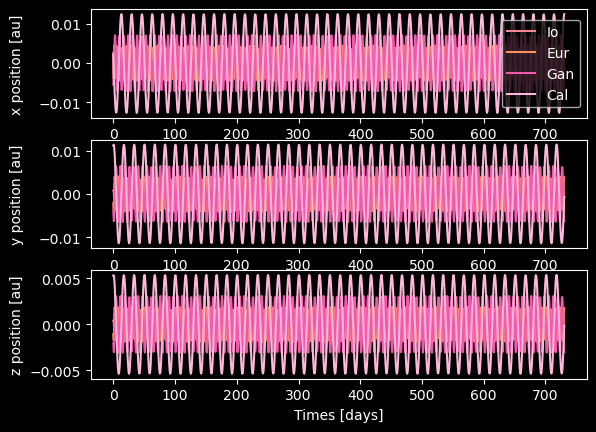

In [5]:
using PyPlot
plt.style.use("dark_background")
mean_sma=[422e3,671e3,1070e3,1883e3]
# fig,(axes)=subplots(2,2,figsize=(8,6),sharex=true,sharey=true)
fig,(ax,ax2,ax3)=subplots(3)
ax.set_prop_cycle(co_cycle)
ax2.set_prop_cycle(co_cycle)
ax3.set_prop_cycle(co_cycle)
for i=1:4
#     axes[i].axhline(mean_sma[i],ls="--",label="avg semi-major axis")
    ax.plot(collect(times).-times[1],pos[1,i,:]./AU,label=obj_names[i])
    ax2.plot(collect(times).-times[1],pos[2,i,:]./AU,label=obj_names[i])
    ax3.plot(collect(times).-times[1],pos[3,i,:]./AU,label=obj_names[i])
end
ax.legend()
ax3.set_xlabel("Times [days]")
ax.set_ylabel("x position [au]");ax2.set_ylabel("y position [au]");ax3.set_ylabel("z position [au]");
fig.align_ylabels()
# fig.tight_layout()

savefig("galilean_moon_positions_J2000.png",dpi=150)

Find the observer location required to see Io and Europa transiting Jupiter

In [6]:
n_obs=calc_obs_loc(pos[:,1,1],vel[:,1,1],pos[:,2,1],vel[:,2,1])

3-element Vector{Float64}:
  0.9944996400592957
 -0.1000625109428052
 -0.030950926088767566

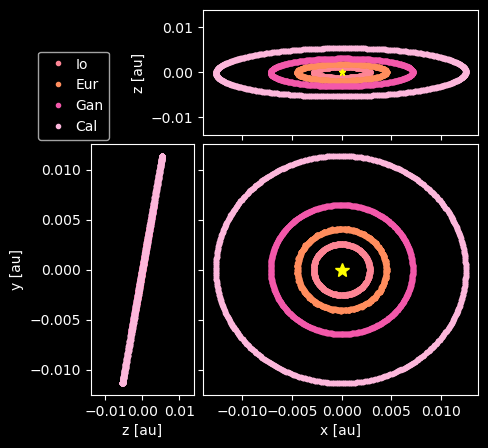

In [7]:
fig=figure(figsize=(5,5))
# ax=fig.add_subplot(111)
# ax1=plt.subplot2grid((2,2),(0,0),rowspan=2)
# ax3=plt.subplot2grid((2,2),(1,0))
plt.style.use("dark_background")
gs = fig.add_gridspec(2, 2, width_ratios=(1.5, 4), 
                            height_ratios=(1, 2),wspace=0.05, hspace=0.05)
ax1 = fig.add_subplot(gs[2, 2])
ax2 = fig.add_subplot(gs[1, 2])
ax3 = fig.add_subplot(gs[2, 1])
ax1.set_prop_cycle(co_cycle)
ax2.set_prop_cycle(co_cycle)
ax3.set_prop_cycle(co_cycle)

# ax3.plot(0,0,marker="*",color="yellow")
for i=1:4
    ax1.plot(pos[1,i,:]./AU,pos[2,i,:]./AU,label=obj_names[i],".")
    ax2.plot(pos[1,i,:]./AU,pos[3,i,:]./AU,".")
    ax3.plot(pos[3,i,:]./AU,pos[2,i,:]./AU,".")
end
axes_limit = 1.1* maximum(abs.(pos[:,:,:]./AU))
ax2.set_ylim(-axes_limit,axes_limit);ax3.set_xlim(-axes_limit,axes_limit);
ax1.plot(0,0,marker="*",color="yellow",ms=10)
ax2.plot(0,0,marker="*",color="yellow",ms=5)
ax2.tick_params(labelbottom=false);ax1.tick_params(labelleft=false)
ax1.set_xlabel("x [au]");ax2.set_ylabel("z [au]")
ax3.set_xlabel("z [au]");ax3.set_ylabel("y [au]");
fig.legend(bbox_to_anchor=(0.075,0.705,0.10,.105),handletextpad=.25)
# # plot(n_obs[1].*range(0,stop=0.01,length=100),n_obs[2].*range(0,stop=0.01,length=100))

# # ax1.plot([0,n_obs[1]],[0,n_obs[2]],"k--",linewidth=1,alpha=0.5,zorder=1)
# # ax1.annotate(L"\sphericalangle",xy=[0.195;1.015],xycoords="data",fontsize="medium",rotation=-104.37)
savefig("galilean_moon_positions3D_J2000.png",dpi=150)

Find observed transit time $t_{obs}$ (O) using JPL Ephemeris simulations 
(assuming that moons are co-planar, and from same observer)

In [8]:
# observed transit times: 
tt_IO=transit_times(naifId.id[:io],eph,times,1.769,1.0,n_obs,10);
tt_EUR=transit_times(naifId.id[:europa],eph,times,3.551,1.0,n_obs,10);
tt_GAN=transit_times(naifId.id[:ganymede],eph,times,7.155,1.0,n_obs,10);
tt_CAL=transit_times(naifId.id[:callisto],eph,times,16.69,1.0,n_obs,10);

## Add Gaussian noise

In [9]:
# add some level of Gaussian error: (assume same error for all moons)
sigIO,noiseIO=fixed_noise(tt_IO,30);
sigEUR,noiseEUR=fixed_noise(tt_EUR,30);
sigGAN,noiseGAN=fixed_noise(tt_GAN,30);
sigCAL,noiseCAL=fixed_noise(tt_CAL,30);

In [10]:
noise = [noiseIO;noiseEUR;noiseGAN;noiseCAL];

In [11]:
tt_IO[1:5].-jd_start

5-element Vector{Float64}:
 1.6523410007357597
 3.4214478274807334
 5.190538692753762
 6.9596624076366425
 8.728754877578467

Perform linear regression, given guess of period from median of transit times

In [12]:
using Statistics
P1_est = median(diff(tt_IO))
P2_est = median(diff(tt_EUR))
P3_est = median(diff(tt_GAN))
P4_est = median(diff(tt_CAL))
println("Period Estimates:")
println(P1_est,'\n',P2_est,'\n',P3_est,'\n',P4_est)

Period Estimates:
1.7691162312403321
3.5512409270741045
7.1545246611349285
16.689010438509285


In [11]:
#Period values from PlanetBodyData.pdf
# 1.769
# 3.551
# 7.155
# 16.69

In [13]:
x_io,t0_io,per_io=linear_fit(tt_IO+noiseIO,1.769,sigIO)
x_eur,t0_eur,per_eur=linear_fit(tt_EUR+noiseEUR,3.551,sigEUR)
x_gan,t0_gan,per_gan=linear_fit(tt_GAN+noiseGAN,7.155,sigGAN)
x_cal,t0_cal,per_cal=linear_fit(tt_CAL+noiseCAL,16.69,sigCAL)

([1.0 1.0 … 1.0 1.0; 0.0 1.0 … 42.0 43.0], 2.451557741160017e6, 16.68904689550489)

In [14]:
x_io[:,:] # print to check epochs/transit numbers

2×412 Matrix{Float64}:
 1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  …    1.0    1.0    1.0    1.0    1.0
 0.0  1.0  2.0  3.0  4.0  5.0  6.0  7.0     407.0  408.0  409.0  410.0  411.0

In [15]:
tt0=[t0_io;t0_eur;t0_gan;t0_cal].-jd_start

4-element Vector{Float64}:
  1.650421831291169
  1.3939980794675648
  2.66029943106696
 12.741160016972572

In [16]:
println("Period from regression:")
per = [per_io, per_eur,per_gan, per_cal]

Period from regression:


4-element Vector{Float64}:
  1.7691365665986354
  3.55119120917901
  7.154553739955999
 16.68904689550489

## Inspect period ratios

In [17]:
println("Period Ratios:")
for i =1:4
    for j = i:4
        if i != j
        println(obj_names[i],"-",obj_names[j]," ratio: ",per[j]/per[i])
    end
end
end

Period Ratios:
Io-Eur ratio: 2.0073019099970195
Io-Gan ratio: 4.044093528467073
Io-Cal ratio: 9.43344183292275
Eur-Gan ratio: 2.0146912172634153
Eur-Cal ratio: 4.699563023350462
Gan-Cal ratio: 2.3326468011976287


Period ratios for Io-Europa-Ganymede are near integer values (1:2:4). Close to resonances, a combination of changes in semi-major axis and eccentricity leads to TTV cycles whose periods depend on the seperation from resonance.

In [18]:
# transit number (or Epoch) is second column of x
nt_io=x_io[2,:]
nt_eur=x_eur[2,:]
nt_gan=x_gan[2,:]
nt_cal=x_cal[2,:];

Compute calculted linear transit times (C) assuming constant period (i.e. the linear empheris)

$t_{calc} = t_{0} + Per \times E$  

In [19]:
tt0_IO  = collect(t0_io .+ per_io .* range(0,stop=length(tt_IO)-1,length=length(tt_IO))) ;
tt0_EUR  = collect(t0_eur .+ per_eur .* range(0,stop=length(tt_EUR)-1,length=length(tt_EUR))) ;
tt0_GAN  = collect(t0_gan .+ per_gan .* range(0,stop=length(tt_GAN)-1,length=length(tt_GAN))) ;
tt0_CAL  = collect(t0_cal .+ per_cal .* range(0,stop=length(tt_CAL)-1,length=length(tt_CAL))) ;
nt1,nt2,nt3,nt4=length(tt_IO),length(tt_EUR),length(tt_GAN),length(tt_CAL)

(412, 206, 102, 44)

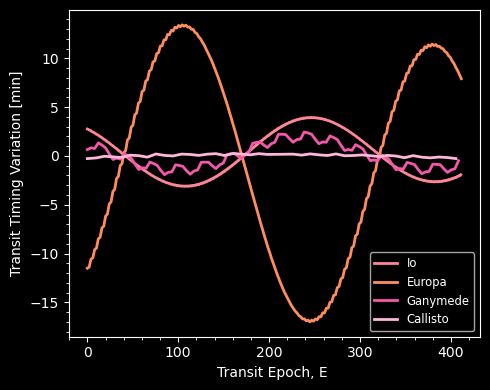

In [20]:
# rc("font",family="sans-serif")
fig,ax=subplots(1,figsize=(5,4))
ax.set_prop_cycle(co_cycle)
ax.plot((tt_IO.-t0_io)/per_io,(tt_IO.-tt0_IO).*24*60,label="Io",lw=2)
ax.plot((tt_EUR.-t0_eur)/per_io,(tt_EUR.-tt0_EUR).*24*60,label="Europa",lw=2)
ax.plot((tt_GAN.-t0_gan)/per_io,(tt_GAN.-tt0_GAN).*24*60,label="Ganymede",lw=2)
ax.plot((tt_CAL.-t0_cal)/per_io,(tt_CAL.-tt0_CAL).*24*60,label="Callisto",lw=2)
ax.set_xlabel("Transit Epoch, E ")
ax.set_ylabel("Transit Timing Variation [min]")
ax.legend(fontsize="small")
tight_layout()
ax.minorticks_on()
savefig("galilean_TTVs_J2000.png",dpi=150)

Io, Europa, and Ganymede vary on same timescale (the fact that all three vary together is related to the Laplace resonance) as expected for pairs of planetary satellites.

TTVs of Io and Ganymede are anti-correlated with those of Europa (conservation of energy within the system)

TTVs on Europa are larger than others because Io and Ganymede (it's adjacent bodies) are more massive than Europa.

Callisto's TTVs are on a longer timescale (Q: why?)

In [21]:
println("Semi-amplitude of transit time variations (i.e. maximum absolute value)")
println("Io: ",maximum(abs.(tt_IO.-tt0_IO).*24*60))
println("Europa: ",maximum(abs.(tt_EUR.-tt0_EUR).*24*60))
println("Ganymede: ",maximum(abs.(tt_GAN.-tt0_GAN).*24*60))
println("Callisto: ",maximum(abs.(tt_CAL.-tt0_CAL).*24*60))

Semi-amplitude of transit time variations (i.e. maximum absolute value)
Io: 3.958371877670288
Europa: 17.008591443300247
Ganymede: 2.4563180655241013
Callisto: 0.26863597333431244


want minimum of $\chi^2 \equiv \sum \frac{(t_{model} - t_{obs})^2}{\sigma^2}$

- Save cartesian positions and velocities. 
- Save data with transiting body, ntrans, transit time, and transit time errors.

In [22]:
# tt=[tt_IO;tt_EUR;tt_GAN;tt_CAL]
# sigtt=[sigIO;sigEUR;sigGAN;sigCAL];
tt=[tt_IO+noiseIO;tt_EUR+noiseEUR;tt_GAN+noiseGAN;tt_CAL+noiseCAL].-jd_start
sigtt=[sigIO;sigEUR;sigGAN;sigCAL]
tt0=[tt0_IO;tt0_EUR;tt0_GAN;tt0_CAL].-jd_start;

In [23]:
noise_free_tt = [tt_IO;tt_EUR;tt_GAN;tt_CAL].- jd_start
isapprox(tt .- noise,noise_free_tt)

true

In [24]:
body = zeros((nt1+nt2+nt3+nt4))
body[1:nt1] .= 1.0
body[nt1+1:nt1+nt2] .= 2.0
body[nt1+nt2+1:nt1+nt2+nt3].= 3.0
body[nt1+nt2+nt3+1:end] .= 4.0;
linear_epochs = [nt_io;nt_eur;nt_gan;nt_cal];

In [25]:

name="galileo_moons_data_noiseless_J2000.txt"
println("Create ",name)
open(name,"w+") do io
    println(io,"Orbits integrated with JPL ephemerides, version jup365.bsp starting at $jd_start .")

println(io,"These true transit times include no white noise.")
println(io,"#body",'\t',"ntrans",'\t',"tt")
    for i=1:length(tt)
      println(io,body[i],'\t',linear_epochs[i],'\t',noise_free_tt[i],)
    end
end
# =

Create galileo_moons_data_noiseless_J2000.txt


In [26]:
info=["Positions, Velocities and Acceleration arrays.
    Units are [AU] , [AU/day], [AU/day^2]"]

1-element Vector{String}:
 "Positions, Velocities and Acceleration arrays.\n    Units are [AU] , [AU/day], [AU/day^2]"

In [27]:
pos_IO = pos[:,1,:]
vel_IO = vel[:,1,:]
acc_IO = acc[:,1,:]#%
pos_EUR = pos[:,2,:]
vel_EUR = vel[:,2,:]
acc_EUR = acc[:,2,:]#
pos_GAN = pos[:,3,:]
vel_GAN = vel[:,3,:]
acc_GAN = acc[:,3,:]#
pos_CAL = pos[:,4,:]
vel_CAL = vel[:,4,:]
acc_CAL = acc[:,4,:];

In [28]:
using JLD2
# pva_IO
# pva_EUR
# pva_GAN
# pva_CAL
@save "jup_moon_cartesians_J2000.jld2" info times pos_IO vel_IO acc_IO pos_EUR vel_EUR acc_EUR pos_GAN vel_GAN acc_GAN pos_CAL vel_CAL acc_CAL#pva_IO pva_EUR pva_GAN pva_CAL
# =#

[ Info: Precompiling JLD2 [033835bb-8acc-5ee8-8aae-3f567f8a3819]


In [29]:

name="galileo_moons_data_J2000.txt"
println("Create ",name)
open(name,"w+") do io
    println(io,"Orbits integrated with JPL ephemerides, version jup365.bsp starting at $jd_start .")

println(io,"The synthetic times include Normally sampled noise with zero mean and 30 second standard deviation.")
println(io,"#body",'\t',"ntrans",'\t',"tt",'\t',"sigtt")
    for i=1:length(tt)
      println(io,body[i],'\t',linear_epochs[i],'\t',tt[i],'\t',sigtt[i])
    end
end
# =#

Create galileo_moons_data_J2000.txt


## Fit all four moons

In [30]:
using TTVFaster
p1=TTVFaster.Planet_plane_hk((3e-5),per_io,t0_io.-jd_start,0.01,0.01)
p2=TTVFaster.Planet_plane_hk((3e-5),per_eur,t0_eur.-jd_start,0.01,0.01)
p3=TTVFaster.Planet_plane_hk((3e-5),per_gan,t0_gan.-jd_start,0.01,0.01)
p4=TTVFaster.Planet_plane_hk((3e-5),per_cal,t0_cal.-jd_start,0.01,0.01)

Planet_plane_hk{Float64}(3.0e-5, 16.68904689550489, 12.741160016972572, 0.01, 0.01)

In [31]:
# Okay,now let's do a 4-moon fit:
# param_names = mass ratio,period,initial transit time,e*cos(omega),e*sin(omega)
init_param = [(3e-5),per_io,t0_io.-jd_start,0.01,0.01,
            (3e-5),per_eur,t0_eur.-jd_start,0.01,0.01,
            (3e-5),per_gan,t0_gan.-jd_start,0.01,0.01,
            (3e-5),per_cal,t0_cal.-jd_start,0.01,0.01]
println("Initial parameters: ",init_param)

Initial parameters: [3.0e-5, 1.7691365665986354, 1.650421831291169, 0.01, 0.01, 3.0e-5, 3.55119120917901, 1.3939980794675648, 0.01, 0.01, 3.0e-5, 7.154553739955999, 2.66029943106696, 0.01, 0.01, 3.0e-5, 16.68904689550489, 12.741160016972572, 0.01, 0.01]


In [32]:
using TTVFaster
# Set up data structure to hold planet properties,passed to TTVFaster
jmax = 5
data=init_param
p1=TTVFaster.Planet_plane_hk(data[1],data[2],data[3],data[4],data[5])
p2=TTVFaster.Planet_plane_hk(data[6],data[7],data[8],data[9],data[10])
p3=TTVFaster.Planet_plane_hk(data[11],data[12],data[13],data[14],data[15])
p4=TTVFaster.Planet_plane_hk(data[16],data[17],data[18],data[19],data[20])
# assuming no transits are skipped/duplicated ########### To Change
time1 = collect(p1.trans0 .+ range(0,stop=nt1-1,length=nt1) .* p1.period)
time2 = collect(p2.trans0 .+ range(0,stop=nt2-1,length=nt2) .* p2.period)
time3 = collect(p3.trans0 .+ range(0,stop=nt3-1,length=nt3) .* p3.period)
time4 = collect(p4.trans0 .+ range(0,stop=nt4-1,length=nt4) .* p4.period)
##########
# Initialize the computation of the Laplace coefficients:
ttv1 = zeros(nt1)
ttv2 = zeros(nt2)
ttv3 = zeros(nt3)
ttv4 = zeros(nt4)
# # Need first call to TTVFaster,without optimizing; Q: why?
dummy=TTVFaster.compute_ttv!(jmax,p1,p2,time1,time2,ttv1,ttv2)

In [43]:
function new_wrapper(tt0::Vector{Float64},nplanet::Int64,ntrans::Vector{Int64},
        params::Vector{T},jmax::Integer=5) where T<:Real
  # These lines need modification for different choices of parameters:
  n1,n2= ntrans[1:2]
  # println(n1, " ", n2)

  # Call ttv_nplanet:
  ttv = TTVFaster.ttv_nplanet(nplanet,jmax,ntrans,params[1:5*nplanet])
  # We measure transit times,not TTVs,so add back in the linear ephemeris:
  per1 = params[2]; t01 = params[3]
  tt1 = collect(range(t01,stop = t01+per1*(n1-1),length = n1)) 
  for i=1:n1
    tt1[i]+= ttv[1,i]
  end
  per2 = params[7];  t02 = params[8]
  tt2 = collect(range(t02,stop = t02+per2*(n2-1),length = n2)) 
  for i=1:n2
    tt2[i] += ttv[2,i]
  end
#     if nplanet>2
    n3 = ntrans[3]
  per3 = params[12];  t03 = params[13]
  tt3 = collect(range(t03,stop = t03+per3*(n3-1),length = n3)) 
  for i=1:n3
    tt3[i] += ttv[3,i]
  end
#   return [tt1;tt2;tt3]
#     end
    if nplanet == 4
        n4 = ntrans[4]
      per4 = params[17];  t04 = params[18]
      tt4 = collect(range(t04,stop = t04+per4*(n4-1),length = n4)) 
      for i=1:n4
        tt4[i] += ttv[4,i]
      end
  # If transit times of additional planets were observable these would need to be added in.
      return [tt1;tt2;tt3;tt4]  
    end
    return [tt1;tt2;tt3]
end


function chisquare(tt0,nplanet,ntrans,params,tt,sigtt,jmax,return_ttmodel=false)
  chisq = 0.0  
    
  # println(params,tt[1],sigtt[1])
  tt_model = new_wrapper(tt0,nplanet,ntrans,params,jmax)
#println(length(tt_model))
  for j=1:length(tt_model)
    chisq += (tt[j]-tt_model[j])^2/sigtt[j]^2
  end
    if return_ttmodel
  return chisq, tt_model
        else 
        return chisq
    end
end

chisquare (generic function with 2 methods)

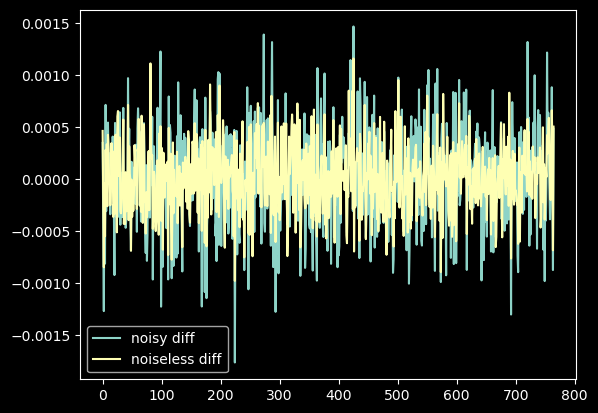

PyObject <matplotlib.legend.Legend object at 0x7f88e954bc70>

In [68]:
# plot(gal["tt"].-tt,label="noisy diff")
# plot(gal["tt"].-noise_free_tt,label="noiseless diff")
legend()

use already saved values.

In [21]:
using JLD2
gal=jldopen("galileo_4moon_fit_noprior_2yrs_full.jld2","r")

JLDFile /Users/bethleelindor/work/washington/galileo/galileo_4moon_fit_noprior_2yrs_full.jld2 (read-only)
 ├─🔢 fit
 ├─🔢 cov
 ├─🔢 lprob_best_s4
 ├─🔢 tt
 ├─🔢 tt0
 └─🔢 sigtt

In [34]:
# sum([nt1,nt2,nt3,nt4])
length(tt0),length(tt),length(sigtt)

(764, 764, 764)

In [35]:
# chi2,ttmodel=chisquare(gal["tt0"],4,[nt1,nt2,nt3,nt4],init_param,gal["tt"],gal["sigtt"],5,true)
chi2,ttmodel=chisquare(tt0,4,[nt1,nt2,nt3,nt4],init_param,tt,sigtt,5,true)

(866358.0361880005, [1.6549890499266169, 3.423789022155318, 5.192572537603514, 6.961374308378719, 8.730156004011441, 10.498945221965165, 12.267722496978458, 14.036515555000477, 15.80529374788347, 17.57407618619041  …  580.1686783984622, 596.857902556736, 613.5468495104938, 630.2357874836051, 646.9250669847796, 663.6139786161033, 680.3029442305183, 696.9921754354426, 713.6811505648863, 730.3700810073332])

In [36]:
using LsqFit
function find_fit(init_param,tt0,tt,sigtt,ntrans)
    weight = ones(length(sigtt))./ sigtt.^2 #assigns each data point stat weight d.t. noise = 1/σ^2
    param1 = init_param .+ 100.0
    nplanet = length(ntrans)
    niter = 0
    while maximum(abs.(param1 .- init_param)) > 1e-5 && niter < 20
        param1 = init_param
        res = curve_fit((tt0,params) -> new_wrapper(tt0,nplanet,ntrans,params,jmax),tt0,tt,weight,init_param)
        init_param = res.param
        niter += 1
        # println("init_param: ",init_param)
        println("New Initial chi-square: ",chisquare(tt0,nplanet,ntrans,init_param,tt,sigtt,jmax))
    end
    println("New initial fit: ",init_param," in ",niter," iterations.")
    return init_param
end

[ Info: Precompiling LsqFit [2fda8390-95c7-5789-9bda-21331edee243]


find_fit (generic function with 1 method)

In [29]:
fitted_param_all4 = find_fit(init_param,gal["tt0"],gal["tt"],gal["sigtt"],[nt1,nt2,nt3,nt4])

New Initial chi-square: 697.4271094401809
New Initial chi-square: 697.4271094401809
New initial fit: [0.0001088932668185464, 1.769137932678446, 1.376131115136331, -0.00028508331728037596, 0.0012423121350615262, 2.7649076871415018e-5, 3.5511811007620353, 1.5715054139615774, 0.0009707512941763904, 0.003303092456790881, 8.428572838382087e-5, 7.1545539600853845, 3.754479871278994, 0.003930362265331716, 0.00924676614309599, 5.521980553466052e-5, 16.68904744192079, 9.79826341145552, 0.011198916883678963, 0.02717172442056033] in 2 iterations.


20-element Vector{Float64}:
  0.0001088932668185464
  1.769137932678446
  1.376131115136331
 -0.00028508331728037596
  0.0012423121350615262
  2.7649076871415018e-5
  3.5511811007620353
  1.5715054139615774
  0.0009707512941763904
  0.003303092456790881
  8.428572838382087e-5
  7.1545539600853845
  3.754479871278994
  0.003930362265331716
  0.00924676614309599
  5.521980553466052e-5
 16.68904744192079
  9.79826341145552
  0.011198916883678963
  0.02717172442056033

In [44]:
# for J2000
fitted_param_all4_J2000 =find_fit(init_param,tt0,tt,sigtt,[nt1,nt2,nt3,nt4])

New Initial chi-square: 804.795806482018
New Initial chi-square: 804.795806482018
New initial fit: [1.3353694904837814e-5, 1.7691377469554421, 1.650490448236954, 0.0001519032789923338, 0.0008384238958172193, 1.5345738190344863e-5, 3.551180418327295, 1.393725719287811, -0.001979417938420335, 0.002117807182465435, 6.91225643518818e-5, 7.154556065199439, 2.660366039164678, -0.006501234049062438, 0.0048571346999682265, 5.947018085345879e-5, 16.689046994041792, 12.741152653245425, -0.017557435012348556, 0.009120692334698905] in 2 iterations.


20-element Vector{Float64}:
  1.3353694904837814e-5
  1.7691377469554421
  1.650490448236954
  0.0001519032789923338
  0.0008384238958172193
  1.5345738190344863e-5
  3.551180418327295
  1.393725719287811
 -0.001979417938420335
  0.002117807182465435
  6.91225643518818e-5
  7.154556065199439
  2.660366039164678
 -0.006501234049062438
  0.0048571346999682265
  5.947018085345879e-5
 16.689046994041792
 12.741152653245425
 -0.017557435012348556
  0.009120692334698905

In [30]:
old_fitted_param=[0.00010889328032298237
  1.7691379326784136
  1.376131115144384
 -0.0002850807926667969
  0.0012423107544919723
  2.7649082850079688e-5
  3.5511811007621454
  1.5715054139497764
  0.0009707593477381093
  0.003303088737938682
  8.428576241841986e-5
  7.154553960086175
  3.7544798712296426
  0.0039303852981230035
  0.009246755719435498
  5.521983328393051e-5
 16.689047441920724
  9.79826341144936
  0.01119906231236957
  0.02717170100877328];
maximum(abs.(old_fitted_param .- fitted_param_all4))#init_param

1.4542869060732433e-7

In [217]:
fitted_param_nonoise=[2.2126043976578172e-5, 1.7691379502481228, 2.4430013761121123e6, 0.007751751099312117, 0.005628408764951272, 8.11786379650111e-6, 3.5511794691007053, 2.4430015717005776e6, 0.01155460383822889, 0.014496948831622699, 1.6575952371914217e-5, 7.154553873323255, 2.443003754494242e6, 0.025112483878938364, 0.03932104352551073, 3.6193228266045786e-5, 16.68904360825258, 2.443009798274682e6, -0.010126857401793858, 0.07011702571589983]# in 174 iterations.
# with New Initial chi-square: 34.559731294835316

20-element Vector{Float64}:
  2.2126043976578172e-5
  1.7691379502481228
  2.4430013761121123e6
  0.007751751099312117
  0.005628408764951272
  8.11786379650111e-6
  3.5511794691007053
  2.4430015717005776e6
  0.01155460383822889
  0.014496948831622699
  1.6575952371914217e-5
  7.154553873323255
  2.443003754494242e6
  0.025112483878938364
  0.03932104352551073
  3.6193228266045786e-5
 16.68904360825258
  2.443009798274682e6
 -0.010126857401793858
  0.07011702571589983

# Fit only the three in MMR

In [31]:
chi2,ttmodel=chisquare(gal["tt0"][1:721],3,[nt1,nt2,nt3],init_param[1:15],gal["tt"][1:721],gal["sigtt"][1:721],5,true)

(860413.1166013714, [1.3604043566498618, 3.1294495858854825, 4.898514469553477, 6.667577628320472, 8.436665926096353, 10.20574228589894, 11.974840738743714, 13.743934392939996, 15.513056640387436, 17.28216434769238  …  661.9783233213387, 669.1338528250387, 676.2893312569067, 683.4447498374739, 690.6001003353031, 697.7553751982753, 704.9105676788447, 712.0656719423749, 719.2206831417074, 726.375597459723])

In [347]:
fitted_param_mmr = find_fit(init_param[1:15],gal["tt0"][1:721],gal["tt"][1:721],gal["sigtt"][1:721],[nt1,nt2,nt3])

New Initial chi-square: 726.9503008005253
New Initial chi-square: 726.9503008005253
New initial fit: [0.0001108775671394915, 1.7691379356157302, 1.376130395143807, -0.0002865725290744652, 0.0014423060768409292, 2.7629828778110253e-5, 3.551181084221937, 1.5715070668796605, 0.0009624736103162797, 0.003847440996759272, 8.389588464529516e-5, 7.154553773776345, 3.7544946326807196, 0.003912768955026708, 0.010762544448977692] in 2 iterations.


15-element Vector{Float64}:
  0.0001108775671394915
  1.7691379356157302
  1.376130395143807
 -0.0002865725290744652
  0.0014423060768409292
  2.7629828778110253e-5
  3.551181084221937
  1.5715070668796605
  0.0009624736103162797
  0.003847440996759272
  8.389588464529516e-5
  7.154553773776345
  3.7544946326807196
  0.003912768955026708
  0.010762544448977692

In [45]:
chi2_mmr,ttmodel_mmr=chisquare(tt0[1:720],3,[nt1,nt2,nt3],init_param[1:15],tt[1:720],sigtt[1:720],5,true)

(866364.3001172635, [1.654989631328165, 3.423789341520038, 5.1925722862461, 6.961373684860855, 8.730155517745615, 10.49894514564289, 12.267722584990771, 14.036515583603833, 15.805293963443637, 17.574076721471066  …  660.8684445057969, 668.0234403316105, 675.1785238555213, 682.3336908410238, 689.4889363788695, 696.6442549318447, 703.7996403816484, 710.9550860501298, 718.1105847014604, 725.266128574621])

In [46]:
# for J2000
fitted_param_mmr_J2000 =find_fit(init_param[1:15],tt0[1:720],tt[1:720],sigtt[1:720],[nt1,nt2,nt3])

New Initial chi-square: 825.1561995845025
New Initial chi-square: 825.1561995845025
New initial fit: [1.4705865184839039e-5, 1.7691377448439063, 1.650490921057332, 0.00019674624963458693, 0.0010554038187676133, 1.5107636309533031e-5, 3.5511803894780773, 1.393728607464546, -0.0019981259943524245, 0.002700639788186593, 6.686668181332442e-5, 7.15455619515741, 2.660356176631584, -0.0066143635224104646, 0.006398774206278666] in 2 iterations.


15-element Vector{Float64}:
  1.4705865184839039e-5
  1.7691377448439063
  1.650490921057332
  0.00019674624963458693
  0.0010554038187676133
  1.5107636309533031e-5
  3.5511803894780773
  1.393728607464546
 -0.0019981259943524245
  0.002700639788186593
  6.686668181332442e-5
  7.15455619515741
  2.660356176631584
 -0.0066143635224104646
  0.006398774206278666

## Fit only 2 planets

In [344]:
chi2,ttmodel=chisquare(gal["tt0"][1:619],2,[nt1,nt2],init_param[1:10],gal["tt"][1:619],gal["sigtt"][1:619],5,true)

(539710.2092675357, [1.3603995779749767, 3.129451064716804, 4.898514346389077, 6.667581310552776, 8.43666116931922, 10.205743673109927, 11.974840308150569, 13.74393837875002, 15.513051955512525, 17.282165585477124  …  697.5857568214213, 701.1363701069699, 704.6870219197322, 708.2377133390244, 711.7884453645, 715.3392189141503, 718.8900348224712, 722.4408938387934, 725.9917966257741, 729.5427437580465])

In [348]:
fitted_param_only2 = find_fit(init_param[1:10],gal["tt0"][1:619],gal["tt"][1:619],gal["sigtt"][1:619],[nt1,nt2])

New Initial chi-square: 618.7615751847204
New Initial chi-square: 618.7615751847204
New initial fit: [1.716006335826865e-5, 1.7691379263652047, 1.3761351732165252, 0.01126787436206909, 0.0007145532082732101, 5.1296212592438745e-6, 3.551181084580783, 1.5715081896809666, 0.011577430112065603, 0.0015792170094413103] in 2 iterations.


10-element Vector{Float64}:
 1.716006335826865e-5
 1.7691379263652047
 1.3761351732165252
 0.01126787436206909
 0.0007145532082732101
 5.1296212592438745e-6
 3.551181084580783
 1.5715081896809666
 0.011577430112065603
 0.0015792170094413103

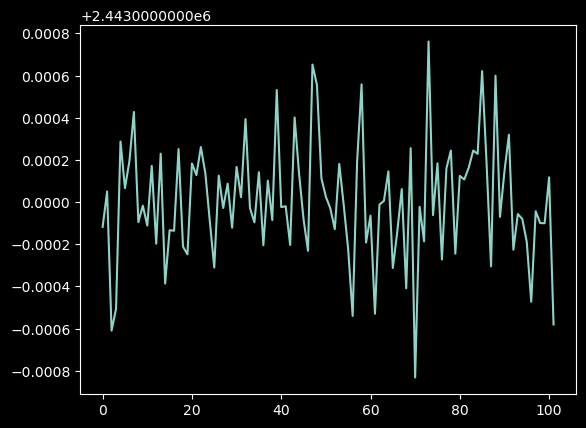

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff43aff3d90>

In [354]:
ttmodel_only2=new_wrapper(gal["tt0"][1:619],2,[nt1,nt2],fitted_param_only2)
# plot(ttmodel_only2.-gal["tt"][1:619])
plot(tt_GAN.-gal["tt"][gan_range],label="noise")
# plot_comp(gal["tt"],gal["tt0"],gal["sigtt"],ttmodel_only2,epochs,[nt1,nt2])

In [49]:
# ModelTimes=new_wrapper(tt0,4,[nt1,nt2,nt3,nt4],fitted_param)
# ttmodel=ModelTimes
epochs = [nt_io,nt_eur,nt_gan,nt_cal]

4-element Vector{Vector{Float64}}:
 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  402.0, 403.0, 404.0, 405.0, 406.0, 407.0, 408.0, 409.0, 410.0, 411.0]
 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  196.0, 197.0, 198.0, 199.0, 200.0, 201.0, 202.0, 203.0, 204.0, 205.0]
 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0]
 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0]

In [48]:
function plot_res(tt,ttmodel,ntrans)
    res_io=tt[1:nt1]-ttmodel[1:nt1]
    res_eur=tt[1+nt1:nt1+nt2]-ttmodel[1+nt1:nt1+nt2]
    res_gan=tt[nt1+nt2+1:nt1+nt2+nt3]-ttmodel[nt1+nt2+1:nt1+nt2+nt3]
    if length(ntrans)==4
        fig,(ax1,ax2,ax3,ax4)=subplots(length(ntrans),figsize=(5,6),dpi=150)
        res_cal=tt[nt1+nt2+nt3+1:end]-ttmodel[nt1+nt2+nt3+1:end]
        ax4.plot(res_cal.*24*60)
        ax4.set_ylabel("Residual [min]");ax4.minorticks_on()
        ax4.set_title("Callisto",loc="left")
        ax4.tick_params(right=true,which="both")
        ax4.set_xlabel("Transit Epoch, E ")
    else
        fig,(ax1,ax2,ax3)=subplots(length(ntrans),figsize=(5,6),dpi=150)
        ax3.set_xlabel("Transit Epoch, E ")
    end
    ax1.plot(res_io.*24*60)
    ax2.plot(res_eur.*24*60)
    ax3.plot(res_gan.*24*60)

    ax1.tick_params(right=true,which="both")
    ax2.tick_params(right=true,which="both")
    ax3.tick_params(right=true,which="both")

    ax1.set_ylabel("Residual [min]");ax1.minorticks_on()
    ax2.set_ylabel("Residual [min]");ax2.minorticks_on()
    ax3.set_ylabel("Residual [min]");ax3.minorticks_on()

    ax1.set_title("Io",loc="left")
    ax2.set_title("Europa",loc="left")
    ax3.set_title("Ganymede",loc="left")

    fig.tight_layout()
    fig.align_labels()	
end

plot_res (generic function with 1 method)

In [50]:
function plot_comp(tt,tt0,sigtt,ttmodel,epochs,ntrans)

    nt1,nt2,nt3=ntrans
    ttv_io_obs =tt[1:nt1]-tt0[1:nt1]
    ttv_eur_obs=tt[1+nt1:nt1+nt2]-tt0[1+nt1:nt1+nt2]
    ttv_gan_obs=tt[nt1+nt2+1:nt1+nt2+nt3]-tt0[nt1+nt2+1:nt1+nt2+nt3]

    ttv_io_model = ttmodel[1:nt1]-tt0[1:nt1]
    ttv_eur_model=ttmodel[1+nt1:nt1+nt2]-tt0[1+nt1:nt1+nt2]
    ttv_gan_model=ttmodel[nt1+nt2+1:nt1+nt2+nt3]-tt0[nt1+nt2+1:nt1+nt2+nt3]

    nt_io,nt_eur,nt_gan = epochs
    sig_io_obs =sigtt[1:nt1]
    sig_eu_obs=sigtt[1+nt1:nt1+nt2]
    sig_ga_obs=sigtt[nt1+nt2+1:nt1+nt2+nt3]

    # ttv_io_model ,ttv_eur_model, ttv_gan_model,ttv_cal_model=ttvmodel
    if length(ntrans)==4
    fig,(ax1,ax2,ax3,ax4)=subplots(length(ntrans),figsize=(5,6),dpi=150)
        nt4=ntrans[4]
        nt_cal = epochs[4]
        ttv_cal_obs=tt[nt1+nt2+nt3+1:end]-tt0[nt1+nt2+nt3+1:end];
        ttv_cal_model=ttmodel[nt1+nt2+nt3+1:end]-tt0[nt1+nt2+nt3+1:end];
        sig_ca_obs=sigtt[nt1+nt2+nt3+1:end]
        ax4.errorbar(nt_cal,ttv_cal_obs.*24*60,sig_ca_obs.*24*60,fmt=".",color="white",mec="hotpink",mfc="white",alpha=0.5)
        ax4.plot(ttv_cal_model.*24*60,zorder=10)
        ax4.tick_params(right=true,which="both")
        ax4.set_ylabel("TTVs [min]");ax4.minorticks_on()
        ax4.set_title("Callisto",loc="left")
        ax4.set_xlabel("Transit Epoch, E ")
    else
    fig,(ax1,ax2,ax3)=subplots(length(ntrans),figsize=(5,6),dpi=150)
    ax3.set_xlabel("Transit Epoch, E ")
    end
    ax.set_prop_cycle(co_cycle)
    ax1.errorbar(nt_io,ttv_io_obs.*24*60,sig_io_obs.*24*60,fmt=".",color="white",mec="hotpink",mfc="white",alpha=0.5)
    ax2.errorbar(nt_eur,ttv_eur_obs.*24*60,sig_eu_obs.*24*60,fmt=".",color="white",mec="hotpink",mfc="white",alpha=0.5)
    ax3.errorbar(nt_gan,ttv_gan_obs.*24*60,sig_ga_obs.*24*60,fmt=".",color="white",mec="hotpink",mfc="white",alpha=0.5)

    ax1.plot(ttv_io_model.*24*60,zorder=10)
    ax2.plot(ttv_eur_model.*24*60,zorder=10)
    ax3.plot(ttv_gan_model.*24*60,zorder=10)

    ax1.tick_params(right=true,which="both")
    ax2.tick_params(right=true,which="both")
    ax3.tick_params(right=true,which="both")


    ax1.set_ylabel("TTVs [min]");ax1.minorticks_on()
    ax2.set_ylabel("TTVs [min]");ax2.minorticks_on()
    ax3.set_ylabel("TTVs [min]");ax3.minorticks_on()


    ax1.set_title("Io",loc="left")
    ax2.set_title("Europa",loc="left")
    ax3.set_title("Ganymede",loc="left")
    fig.tight_layout()
    fig.align_labels()
end


plot_comp (generic function with 1 method)

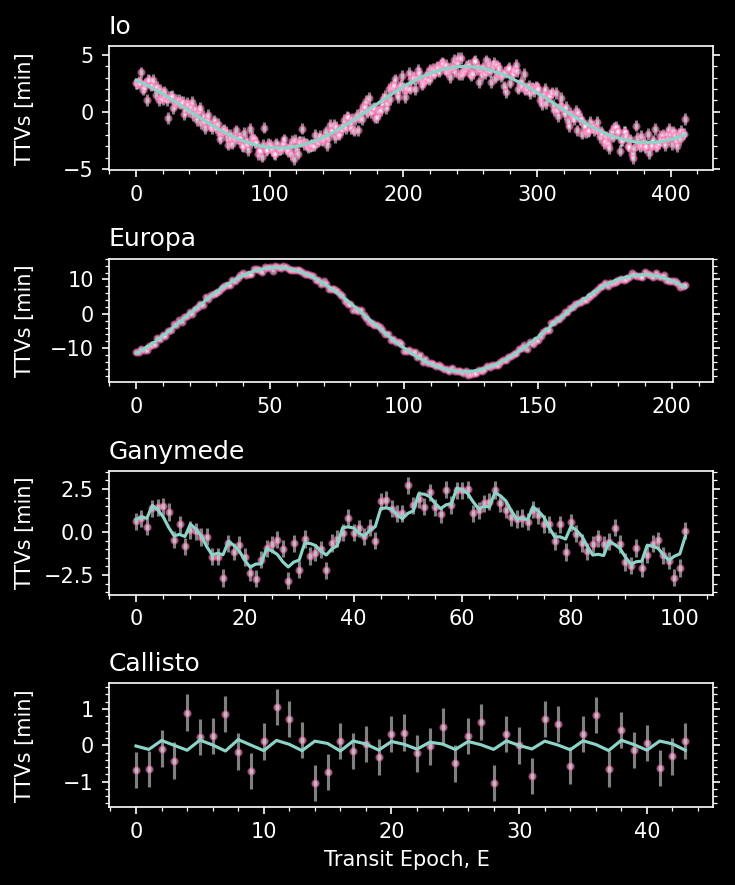

In [52]:
ttmodel_all4_J2000=new_wrapper(tt0,4,[nt1,nt2,nt3,nt4],fitted_param_all4_J2000)
plot_comp(tt,tt0,sigtt,ttmodel_all4_J2000,epochs,[nt1,nt2,nt3,nt4])
savefig("galilean_TTVs_all4fit_J2000.png",dpi=150)

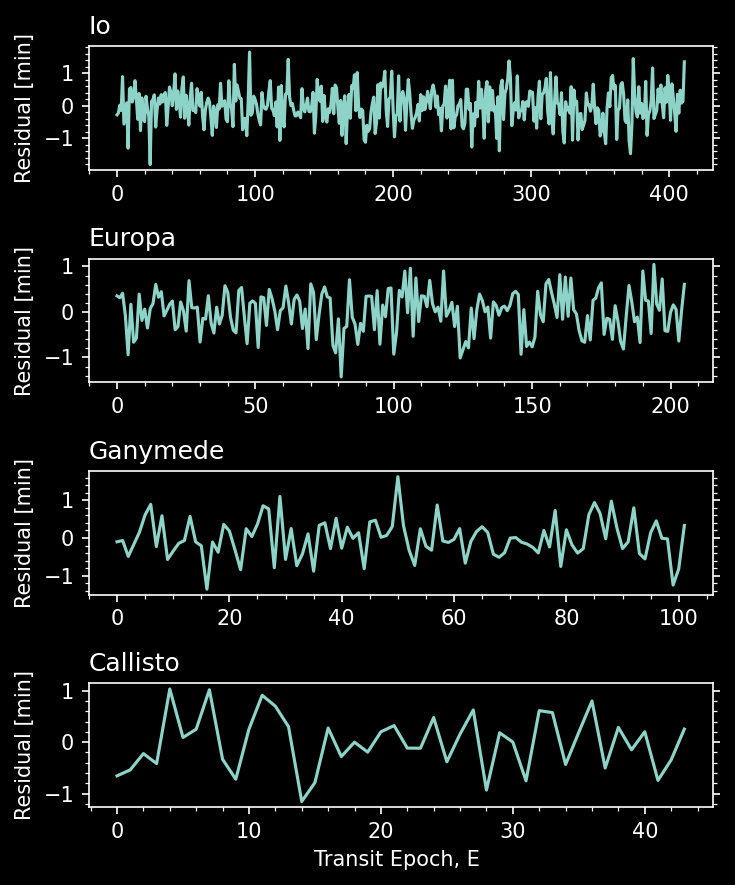

In [54]:
plot_res(tt,ttmodel_all4_J2000,[nt1,nt2,nt3,nt4])
savefig("galilean_TTVs_res_all4fit_J2000.png",dpi=150)

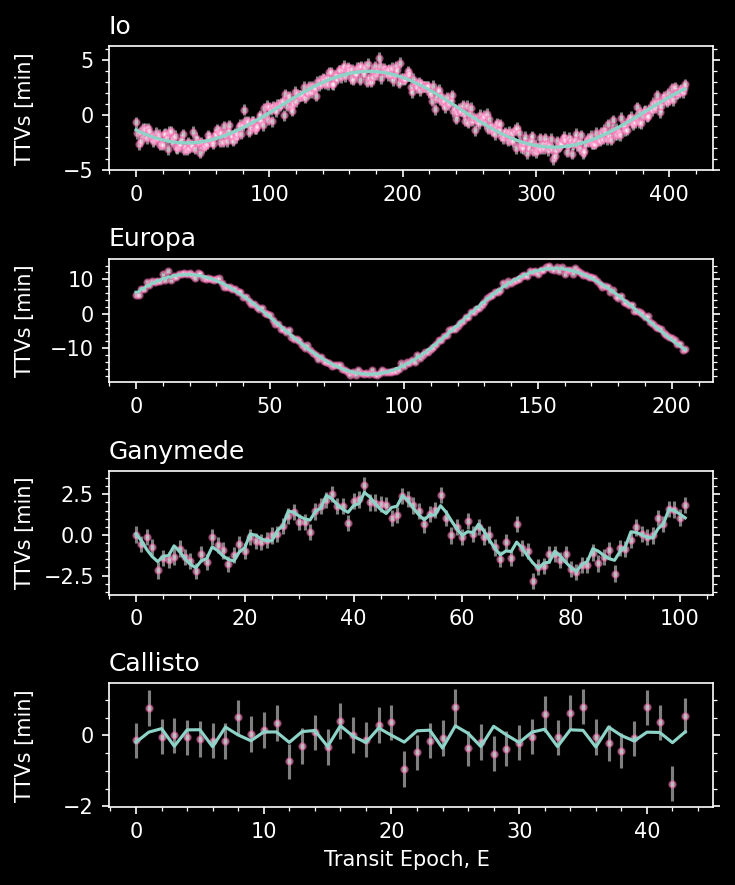

In [232]:
ttmodel_all4=new_wrapper(gal["tt0"],4,[nt1,nt2,nt3,nt4],fitted_param_all4)
# plot_comp(gal["tt"],gal["tt0"],gal["sigtt"],ttmodel_all4,epochs,[nt1,nt2,nt3,nt4])
# savefig("galilean_TTVs_all4fit.png",dpi=150)

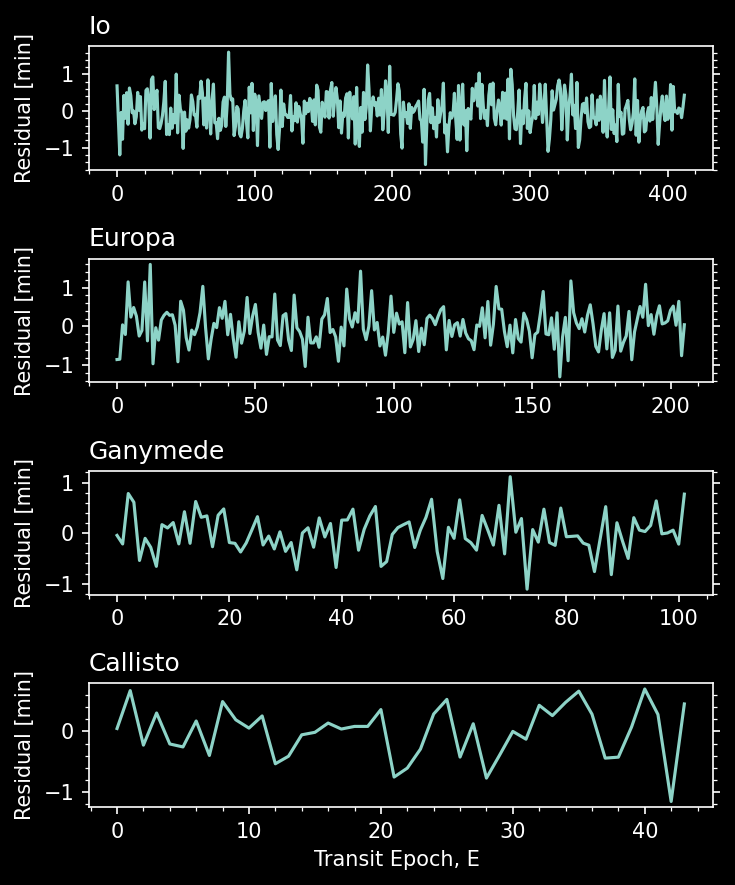

In [95]:
plot_res(gal["tt"],ttmodel_all4,[nt1,nt2,nt3,nt4])
savefig("galilean_TTVs_res_all4fit.png",dpi=150)

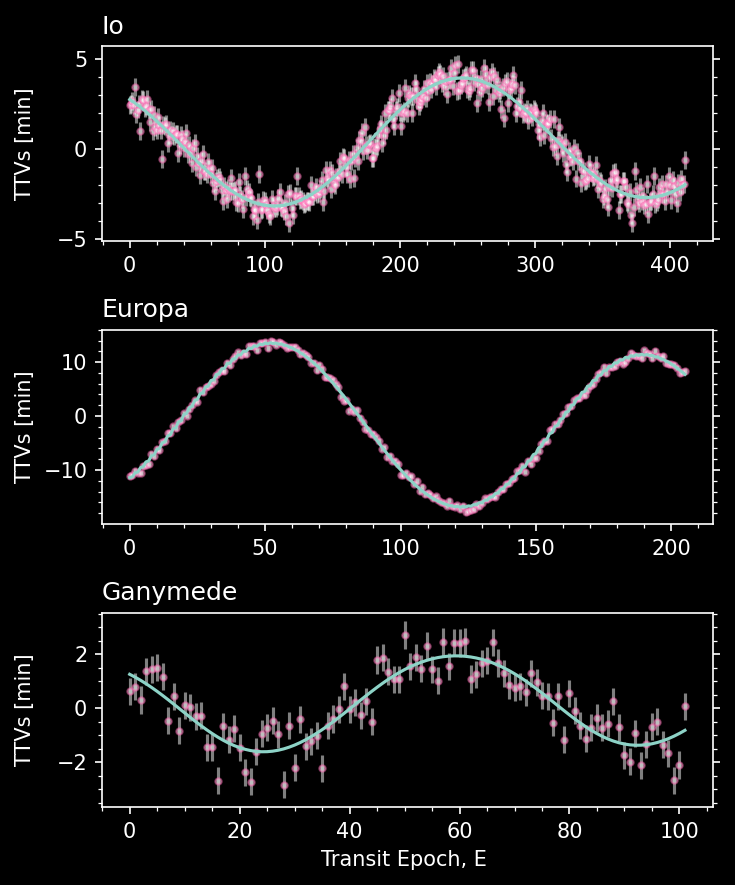

In [53]:
ttmodel_mmr_J2000=new_wrapper(tt0[1:720],3,[nt1,nt2,nt3],fitted_param_mmr_J2000)
plot_comp(tt[1:720],tt0[1:720],sigtt[1:720],ttmodel_mmr_J2000,epochs[1:3],[nt1,nt2,nt3])
savefig("galilean_TTVs_mmrfit_J2000.png",dpi=150)

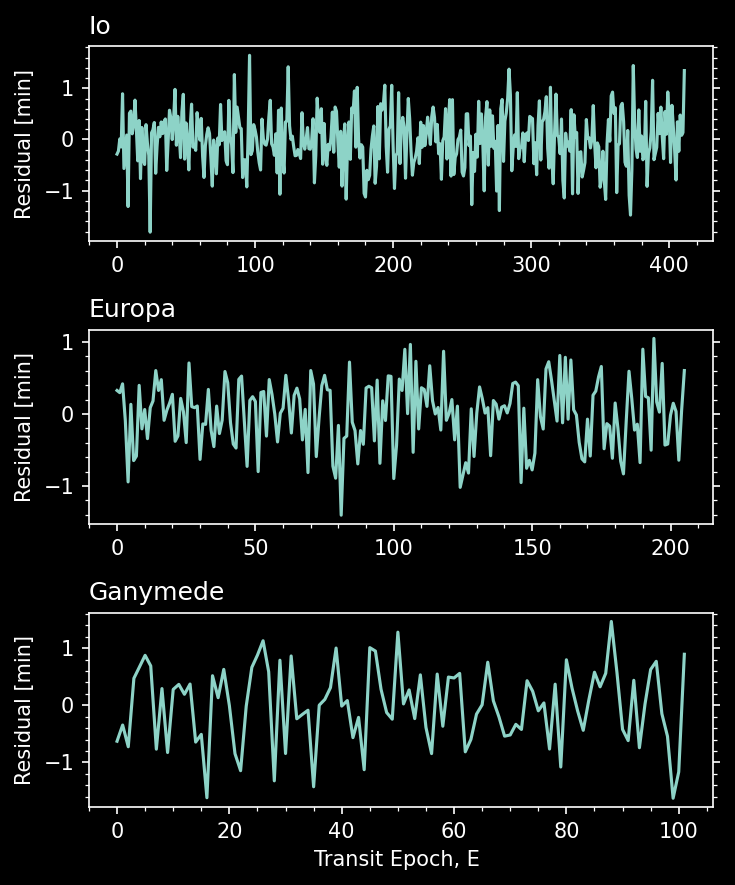

In [55]:
plot_res(tt[1:720],ttmodel_mmr_J2000,[nt1,nt2,nt3])
savefig("galilean_TTVs_res_mmrfit_J2000.png",dpi=150)

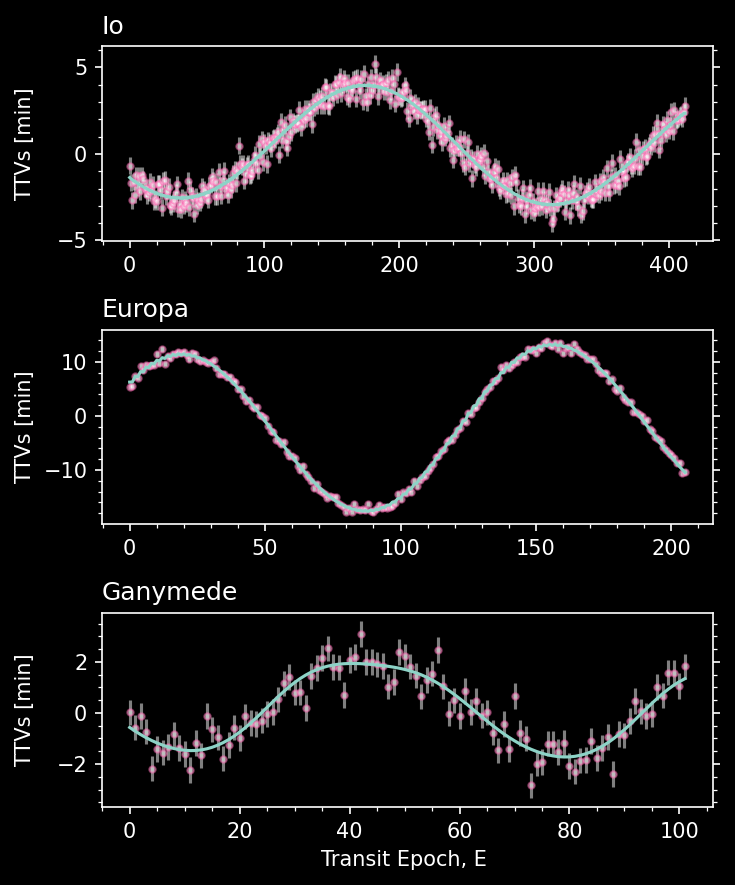

In [231]:
#     savefig("galilean_TTVs_all4fit.png",dpi=150)
ttmodel_mmr=new_wrapper(gal["tt0"][1:721],3,[nt1,nt2,nt3],fitted_param_mmr)
   
plot_comp(gal["tt"][1:721],gal["tt0"][1:721],gal["sigtt"][1:721],ttmodel_mmr,epochs[1:3],[nt1,nt2,nt3])
savefig("galilean_TTVs_mmrfit.png",dpi=150)

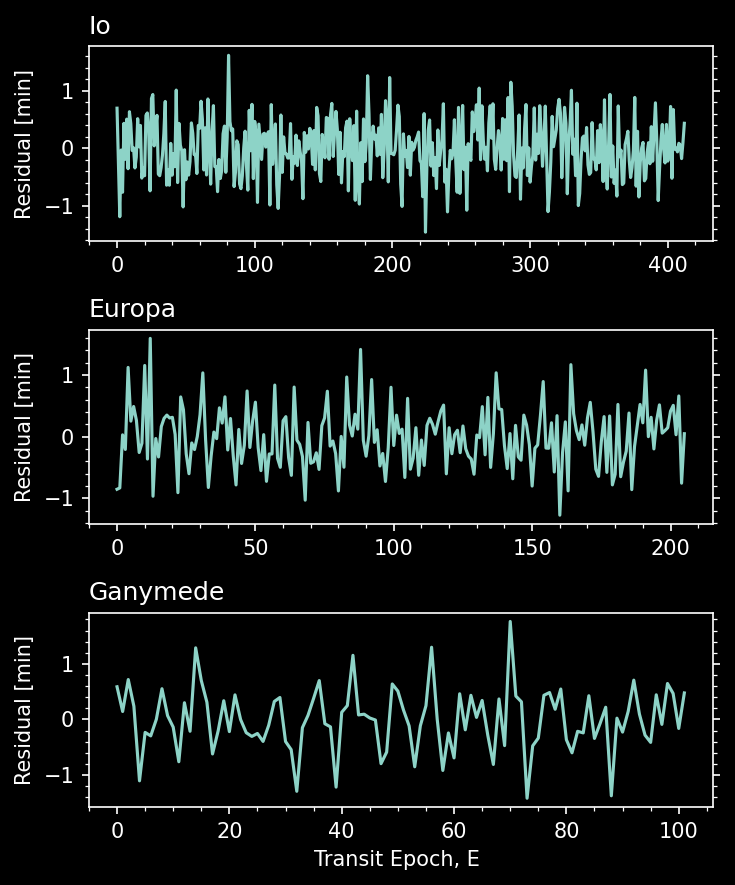

In [230]:
plot_res(gal["tt"][1:721],ttmodel_mmr,[nt1,nt2,nt3])
savefig("galilean_TTVs_res_mmrfit.png",dpi=150)

In [57]:
# gal=jldopen("galileo_4moon_fit_noprior_2yrs_full.jld2","r")
# @save "galileo_3moon_mmr_fit_2yrs_full_J2000.jld2" fitted_param_mmr_J2000 ttmodel_mmr_J2000 
@save "galileo_4moon_fit_2yrs_full_J2000.jld2" fitted_param_all4_J2000 ttmodel_all4_J2000 

In [58]:
ttv1_linial = zeros(3,nt1)
ttv2_linial = zeros(3,nt2)
ttv3_linial = zeros(3,nt3)
ttv1_linial[1,:] .= ttv1
ttv2_linial[1,:] .= ttv2
ttv3_linial[1,:] .= ttv3
# Now, orthogonalize:
coeff1 = sum(ttv1_linial[2,:] .* ttv1_linial[1,:])/sum(ttv1_linial[2,:].^2)
ttv1_linial[2,:] .*= coeff1
ttv1_linial[1,:] .-= ttv1_linial[2,:]
coeff2 = sum(ttv2_linial[2,:] .* ttv2_linial[1,:])/sum(ttv2_linial[2,:].^2)
ttv2_linial[2,:] .*= coeff2
ttv2_linial[1,:] .-= ttv2_linial[2,:]
coeff3 = sum(ttv3_linial[2,:] .* ttv3_linial[1,:])/sum(ttv3_linial[2,:].^2)
ttv3_linial[2,:] .*= coeff3
ttv3_linial[1,:] .-= ttv3_linial[2,:]

102-element view(::Matrix{Float64}, 1, :) with eltype Float64:
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
   ⋮
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN

In [59]:
function subtract_sine(time1,time2,ttv1,ttv2,p1,p2,j)
# Subtracts sine curve from TTVs:
  sin_mod(t,x1,x2,x3) = x1 * sin(t*2pi/x3) + x2 * cos(t*2pi/x3)
  function sin_fit(x)
     return sum((ttvall .- sin_mod.(ttall,x[1],x[2],x[3])).^2)
  end
  ttall = copy(time1); ttvall = copy(ttv1)
  pttv = 1/abs(j/p1-(j+1)/p2)
  ttv_amp =0.5*(maximum(ttv1)-minimum(ttv1))
  # Pick a random phase:
  chisq = Inf
  r1_save = optimize(sin_fit,[ttv_amp,0.0,pttv])
  for i=1:8
    phase = 2pi*(i-0.5)/8
    r1 = optimize(sin_fit,[ttv_amp*cos(phase),ttv_amp*sin(phase),pttv])
    if r1.minimum < chisq
      chisq = r1.minimum
      r1_save = r1
    end
  end
  x01 = r1_save.minimizer
  println("x01: ",x01," minimum: ",chisq)

#  r1 = optimize(sin_fit,[0.5*(maximum(ttv1)-minimum(ttv1)),0.0,pttv])
#  x01 = r1.minimizer
#  println("x01: ",x01)
  ttv1_res = sin_mod.(time1,x01[1],x01[2],x01[3])
  ttv1_chop = ttv1 .- ttv1_res
  ttall = copy(time2); ttvall = copy(ttv2)
  ttv_amp =0.5*(maximum(ttv2)-minimum(ttv2))
  # Pick a random phase:
  chisq = Inf
  r2_save = optimize(sin_fit,[ttv_amp,0.0,pttv])
  for i=1:8
    phase = 2pi*(i-0.5)/8
    r2 = optimize(sin_fit,[ttv_amp*cos(phase),ttv_amp*sin(phase),pttv])
    if r2.minimum < chisq
      chisq = r2.minimum 
      r2_save = r2
    end
  end
  x02 = r2_save.minimizer
  println("x02: ",x02," minimum: ",chisq)
#  r2 = optimize(sin_fit,[-0.5*(maximum(ttv2)-minimum(ttv2)),0.0,pttv])
#  x02 = r2.minimizer
#  println("x02: ",x02)
  ttv2_res = sin_mod.(time2,x02[1],x02[2],x02[3])
  ttv2_chop = ttv2 .- ttv2_res
  return ttv1_chop,ttv2_chop,ttv1_res,ttv2_res
end

subtract_sine (generic function with 1 method)

In [251]:
import Pkg; Pkg.add("Optim")

    Updating registry at `~/.julia/registries/General`
   Resolving package versions...
   Installed PositiveFactorizations ─ v0.2.4
   Installed UnPack ───────────────── v1.0.2
   Installed CodecBzip2 ───────────── v0.8.5
   Installed Parameters ───────────── v0.12.3
   Installed LineSearches ─────────── v7.4.1
   Installed MutableArithmetics ───── v1.6.7
   Installed JSON3 ────────────────── v1.14.3
   Installed StructTypes ──────────── v1.11.0
   Installed Optim ────────────────── v1.11.0
   Installed MathOptInterface ─────── v1.48.0
    Updating `~/work/washington/analytic_ttvs/ttv_ss/Project.toml`
  [429524aa] + Optim v1.11.0
    Updating `~/work/washington/analytic_ttvs/ttv_ss/Manifest.toml`
  [523fee87] + CodecBzip2 v0.8.5
  [0f8b85d8] + JSON3 v1.14.3
  [d3d80556] + LineSearches v7.4.1
  [b8f27783] + MathOptInterface v1.48.0
  [d8a4904e] + MutableArithmetics v1.6.7
  [429524aa] + Optim v1.11.0
  [d96e819e] + Parameters v0.12.3
  [85a6dd25] + PositiveFactorizations v0.2.4
  [856f

In [252]:
using Optim
ttv1_chop,ttv2_chop = subtract_sine(time1,time2,ttv1,ttv2,fitted_param_mmr[2],fitted_param_mmr[7],5)
# ttv3_chop,ttv4_chop,ttv3_res,ttv4_res = subtract_sine(time3,time4,ttv3,ttv4,params[12],params[17],3)

[ Info: Precompiling Optim [429524aa-4258-5aef-a3af-852621145aeb]
┌ Warning: Module NLSolversBase with build ID 4066112070235512 is missing from the cache.
│ This may mean NLSolversBase [d41bc354-129a-5804-8e4c-c37616107c6c] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1030
[ Info: Skipping precompilation since __precompile__(false). Importing Optim [429524aa-4258-5aef-a3af-852621145aeb].
[ Info: Precompiling LineSearches [d3d80556-e9d4-5f37-9878-2ab0fcc64255]
┌ Warning: Module NLSolversBase with build ID 4066112070235512 is missing from the cache.
│ This may mean NLSolversBase [d41bc354-129a-5804-8e4c-c37616107c6c] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1030
[ Info: Skipping precompilation since __precompile__(false). Importing LineSearches [d3d80556-e9d4-5f37-9878-2ab0fcc64255].
[ Info: Precompiling MathOptInterface [b8f27783-ece8-5eb3-8dc8-9495eed66fee]
┌ Warning: Module ForwardDiff wit

x01: [0.011582763798014182, 0.010070121336471751, 0.8829063948135746] minimum: 0.0005645195654500705
x02: [0.014059266701001334, -0.016630783067444546, 1.1807691980444028] minimum: 0.00036319205193740325


([-0.001601612469206145, -0.001521529527320464, -0.0014373286015576612, -0.001357211653650577, -0.0012720517438797752, -0.0011921792235051638, -0.0011061841955477096, -0.0010268341929851113, -0.0009401259263336209, -0.0008615751065126371  …  -0.00047231750990656823, -0.0005003401126557824, -0.0004042376249721886, -0.0004297965000197978, -0.0003327777406905985, -0.00035584575643282136, -0.0002580565586738741, -0.00027861446838562537, -0.00018020644541851157, -0.00019824305839564148], [0.0014040205812048297, 0.0012132396357081646, 0.0010221148577917519, 0.0008311235553259966, 0.0006407399195624101, 0.0004514333045508266, 0.00026366654800758296, 7.789435133510186e-5, -0.00010543826633221953, -0.0002858974283505705  …  0.0007956064465010279, 0.0007320908231777043, 0.000664116653073716, 0.0005917579253087238, 0.0005151068213762322, 0.00043427373545671527, 0.0003493872372716464, 0.0002605939725320687, 0.0001680584952122692, 7.196302544108454e-5], [-0.01353541573723021, -0.013702885311225127,

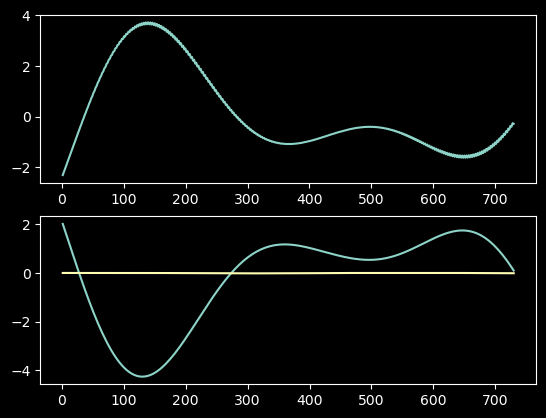

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff435935940>

In [340]:
ax1=subplot(211);ax1.plot(time1,ttv1_chop.*24*60,label="planet e") #; ax1.axis([0,3000,-10,10])
ax2=subplot(212);ax2.plot(time2,ttv2_chop.*24*60,label="planet d")
ax2.plot(time2,ttmodel_mmr[eur_range].-gal["tt0"][eur_range])#; ax2.axis([0,3000,-10,10])
# ax1=subplot(211);ax1.plot(time1,ttv1_linial[2,:].*24*60,label="planet e")

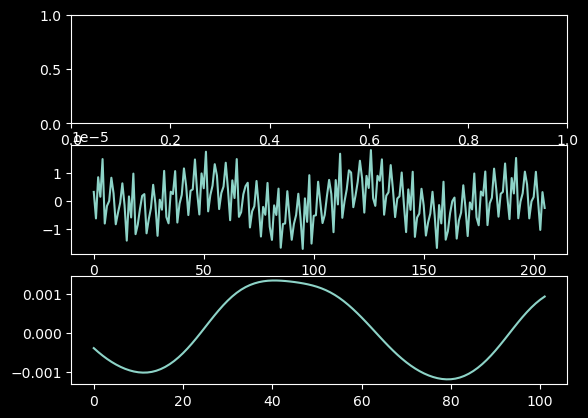

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff4538f6ee0>

In [331]:
fig,(ax,ax2,ax3)=subplots(3)
# ax.s
# ax.plot(ttmodel_mmr[io_range] .- ttmodel_all4[io_range])
ax2.plot(ttmodel_mmr[eur_range] .- ttmodel_all4[eur_range])
ax3.plot(ttmodel_mmr[gan_range] .- gal["tt0"][gan_range])
# fig.supylabel("3-planet model - ")

## Do global fit

In [86]:
fit = curve_fit((tt0,params) -> new_wrapper(tt0,4,[nt1,nt2,nt3,nt4],params,jmax),tt0,tt,weight,fitted_param)
cov=estimate_covar(fit)
nparam=20
Nobs=sum([nt1,nt2,nt3,nt4])
err=[sqrt(cov[i,j]) for i=1:nparam, j=1:nparam if i==j ]
best_s4 = fit.param ##### is this the global p2 fit???
ttmodel_global = ttv_wrapper(tt0,4,[nt1,nt2,nt3,nt4],best_s4,jmax,true)
lprob_best_s4= (1 - Nobs/2) * log(sum((tt-ttmodel).^2 ./sigtt.^2))
# println("Finished 2-planet fit") 
println("New 4-moon chi-square: ",chisquare(tt0,4,[nt1,nt2,nt3,nt4],best_s4,tt,sigtt,jmax))
println("Maximum: ",lprob_best_s4," Param: ",best_s4)

New 4-moon chi-square: 697.4271094454479
Maximum: -2497.832339154549 Param: [0.00010889328032298237, 1.7691379326784136, 1.376131115144384, -0.0002850807926667969, 0.0012423107544919723, 2.7649082850079688e-5, 3.5511811007621454, 1.5715054139497764, 0.0009707593477381093, 0.003303088737938682, 8.428576241841986e-5, 7.154553960086175, 3.7544798712296426, 0.0039303852981230035, 0.009246755719435498, 5.521983328393051e-5, 16.689047441920724, 9.79826341144936, 0.01119906231236957, 0.02717170100877328]


## Run affine invariant markov chain

In [107]:
fitfile=string("galileo_4moon_fit_noprior_2yrs_full.jld2")
p=jldopen(String(fitfile),"r")

JLDFile /Users/bethleelindor/work/washington/jup_moons/galileo_4moon_fit_noprior_2yrs_full.jld2 (read-only)
 ├─🔢 fit
 ├─🔢 cov
 ├─🔢 lprob_best_s4
 ├─🔢 tt
 ├─🔢 tt0
 └─🔢 sigtt

In [109]:
p["fit"].param

20-element Vector{Float64}:
  0.00010889328032298237
  1.7691379326784136
  1.376131115144384
 -0.0002850807926667969
  0.0012423107544919723
  2.7649082850079688e-5
  3.5511811007621454
  1.5715054139497764
  0.0009707593477381093
  0.003303088737938682
  8.428576241841986e-5
  7.154553960086175
  3.7544798712296426
  0.0039303852981230035
  0.009246755719435498
  5.521983328393051e-5
 16.689047441920724
  9.79826341144936
  0.01119906231236957
  0.02717170100877328

In [127]:
include("gal_mc.jl")

MCMC (generic function with 2 methods)

In [128]:
# testing 
nwalkers = 60
nsteps = 10
foutput=string("galileo_4moon_mcmc_2yrs_full.jld2")
MCMC(foutput,best_s4,lprob_best_s4,
    nsteps,nwalkers,
    4,[nt1,nt2,nt3,nt4],
    p["tt0"],p["tt"],p["sigtt"])

20 parameters from fit: [0.00010889328032298237, 1.7691379326784136, 1.376131115144384, -0.0002850807926667969, 0.0012423107544919723, 2.7649082850079688e-5, 3.5511811007621454, 1.5715054139497764, 0.0009707593477381093, 0.003303088737938682, 8.428576241841986e-5, 7.154553960086175, 3.7544798712296426, 0.0039303852981230035, 0.009246755719435498, 5.521983328393051e-5, 16.689047441920724, 9.79826341144936, 0.01119906231236957, 0.02717170100877328]
Maximum log Prob from fit: -2497.832339154549
No Walkers: 60 No. steps: 10
Burn-in Number (ends): 10


In [129]:
mc = jldopen(foutput,"r")

JLDFile /Users/bethleelindor/work/washington/jup_moons/galileo_4moon_mcmc_2yrs_full.jld2 (read-only)
 ├─🔢 par_mcmc
 ├─🔢 lprob_mcmc
 ├─🔢 param
 ├─🔢 nwalkers
 ├─🔢 nsteps
 ├─🔢 iburn
 ├─🔢 chn
 └─🔢 pname

In [130]:
mc["par_mcmc"]

60×10×21 Array{Float64, 3}:
[:, :, 1] =
 0.000108783  0.000108783  0.000108808  …  0.000108836  0.000108836
 0.000108964  0.000108854  0.000108914     0.000108925  0.000108925
 0.000108814  0.000108903  0.000108903     0.000108905  0.000108905
 0.000108881  0.000108881  0.000108925     0.000108933  0.000108933
 0.000108958  0.000108958  0.000108957     0.000108949  0.000108931
 0.00010874   0.00010874   0.00010874   …  0.00010882   0.00010882
 0.000108963  0.00010895   0.00010895      0.000108937  0.000108879
 0.000108851  0.000108855  0.000108855     0.000108855  0.000108867
 0.000108848  0.000108848  0.000108848     0.000108876  0.000108896
 0.00010879   0.00010879   0.00010885      0.000108862  0.000108862
 0.00010893   0.00010893   0.00010893   …  0.000108962  0.000108962
 0.000108907  0.000108907  0.00010892      0.000108858  0.000108858
 0.000108889  0.000108889  0.000108889     0.000108882  0.000108882
 ⋮                                      ⋱               
 0.000109031  0.0001

In [2]:
using NbodyGradient
fitted_param=[0.00010889328032298237, 1.7691379326784136, 1.376131115144384, -0.0002850807926667969, 0.0012423107544919723, 2.7649082850079688e-5, 3.5511811007621454, 1.5715054139497764, 0.0009707593477381093, 0.003303088737938682, 8.428576241841986e-5, 7.154553960086175, 3.7544798712296426, 0.0039303852981230035, 0.009246755719435498, 5.521983328393051e-5, 16.689047441920724, 9.79826341144936, 0.01119906231236957, 0.02717170100877328]
function get_ic(data)
stara=Elements(m=1.0, P=0.0  ,    
    t0=0.0   ,
    ecosω=0.0  ,  
    esinω=0.0  , 
    I=0.0   ,
    Ω=0.0)
io=Elements(m=data[1],P=data[2],t0=data[3],ecosω=data[4],esinω=data[5] ) 
eur=Elements(m=data[6],P=data[7],t0=data[8],ecosω=data[9],esinω=data[10] ) 
gan=Elements(m=data[11],P=data[12],t0=data[13],ecosω=data[14],esinω=data[15] ) 
cal=Elements(m=data[16],P=data[17],t0=data[18],ecosω=data[19],esinω=data[20] ) 
t0=0.0; tmax=100.0;h=1.0
ic=ElementsIC(t0,5,[stara;io;eur;gan;cal])
intr=Integrator(h,t0,tmax)
return ic
end
ic=get_ic(fitted_param)
s=State(ic)
s.x

3×5 Matrix{Float64}:
 -6.95925e-6   0.0281854   -0.0163154  0.010223   0.0630119
 -1.25258e-5  -0.00508235   0.0423917  0.0712271  0.106914
  0.0          0.0          0.0        0.0        0.0

- Save fit to 4 moons for full 2 yrs of data

In [455]:
@save "galileo_4moon_fit_noprior_2yrs_full.jld2" fit cov lprob_best_s4 tt tt0 sigtt

### Find resonances
Resonances are identified by looking at the resonant arguments, which are defined as: 
   $$ \theta = (p + q)\lambda_{\rm out} - p \lambda_{\rm in} - q \omega_{\rm out/in}$$
 where $\lambda_{\rm out}$ and $\lambda_{\rm in}$ are the mean longitudes of the outer and inner bodies, respectively,
 and $\omega_{\rm out}$ is the longitude of pericenter of the outer/inner body.
 The ratio of periods is defined as : $$P_{\rm in}/P_{\rm out} ~= p / (p + q)$$

 If the resonant argument, $\theta$, oscillates but is constrained within some range of angles, then 
 there is a resonance between the inner and outer bodies. We call this libration of the angle $\theta$. 
 The trick is to find what the values of q and p are.  For our case, we can easily see that 
 there are two 2:1 resonances between the moons, so their resonant arguments would follow 
 the function:
    $$\theta = 2 \lambda_{\rm out} - \lambda_{\rm in} - \omega_{\rm out}$$

 To make the plotting easier, we can borrow this helper function that puts angles into 0 to 360 degrees 
 from another example (Fourier analysis & resonances), and define a new one that puts angles
 into -180 to 180 degrees.

In [60]:
function zeroTo360(val)
    while val < 0
        val += 2*pi
    end
    while val > 2*pi
        val -= 2*pi
    end
    return (val*180/pi)
end

function min180To180(val)
    while val < -pi
        val += 2*pi
    end
    while val > pi
        val -= 2*pi
    end
    return (val*180/pi)
end                

min180To180 (generic function with 1 method)

In [61]:
println("α:")
for i =1:4
    for j = i:4
        if i != j
        println(obj_names[i],"-",obj_names[j]," α: ",(per[i]/per[j]).^(2/3))
    end
end
end

α:
Io-Eur α: 0.6284318698633004
Io-Gan α: 0.39396037240222065
Io-Cal α: 0.22398548871255824
Eur-Gan α: 0.6268943242613028
Eur-Cal α: 0.35641968438246246
Gan-Cal α: 0.5685482713572937


In [63]:
GRAV = 1.327e11 # km^3 / Msun/s^2
sma(T,mstar,mpl) = (T^2 * (mstar + mpl)* GRAV / 4π^2)^(1/3)
for i=1:4
   a=sma(fitted_param_all4_J2000[(i-1)*5+2].*24*3600,0.00095,fitted_param_all4_J2000[(i-1)*5+1].*0.00095)./AU
    @show a
end

a = 0.0028140925674591125
a = 0.004477951578481164
a = 0.0071432165107478685
a = 0.012563914744836533


Can compute mean longitudes from TTVFaster, but how to get the longitude of the pericenters? 
- Use Nbody Gradient ?
- compute elements from position vectors, - $\varpi = \Omega + \omega $
- For now, just use the $\omega$ from the fitted results to solve for p and q? note: using fitted masses so plots not truth

In [64]:
function convert_to_elements(x::Vector{T}, v::Vector{T}, mstar::T, m_pl::T, t::T) where T <: AbstractFloat
    R = norm(x)
    v2 = dot(v, v)
    hvec = cross(x, v)
    h = norm(hvec)
    GRAV=1.3275e11 
    Gm = (mstar+m_pl)*GRAV # km3/s2/Msun
    # (2.134)
    a = 1. / (2/R - v2/Gm)
    # (2.135)
    e = sqrt(1 - h^2 / (Gm * a))
    # (2.136)
    hx,hy,hz=hvec
    I = acos(clamp(hz / h, -1, 1))
    # (2.137)
    hz >= 0.0 ? hy *= -1 : hx *= -1
    sinΩ = hx / (h * sin(I))
    cosΩ = hy / (h * sin(I))
    Ω = atan(sinΩ, cosΩ)
    # (2.138)
    sin_ω_plus_f = x[3] / (R * sin(I))
    cos_ω_plus_f = (1 / cos(Ω)) * (x[1] / R + sin(Ω) * sin_ω_plus_f * cos(I))
    ω_plus_f = atan(sin_ω_plus_f, cos_ω_plus_f)
    # (2.139) assuming Rdot = (x.v)/R which is projection of velocity in radial direction
    sinf = a * (1 - e^2) * dot(x, v) / (h * e * R)
    cosf = (1 / e) * (a * (1 - e^2) / R - 1)
    f = atan(sinf, cosf) 
    ω = ω_plus_f - f
    # (2.140)
    # Step 1: Solve for E explicitly from Eq. (2.42)
    cosE = (a - R) / (a * e)
    E = acos(clamp(cosE, -1, 1))
    # Adjust E based on radial velocity
    Rdot = dot(x, v) / R
    if Rdot < 0
        E = 2π - E
    end

    #  Mean anomaly M from Eq. (2.51)
    M = E - e * sin(E)
    #  Mean motion n from Eq. (2.26)
    n_mean = sqrt(Gm / a^3)
    P = 2π/n_mean
    # True longitude from Eq. (2.118)
    ϖ = Ω + ω
    θ = ϖ + f
    #  τ from M and n (Eq. 2.51 rearranged)
    τ = t - M / n_mean
    # Mean longitude, λ from Eq. (2.53)
    λ =  n_mean * (t - τ)
    return (
        a = a/AU, # in astronomical units
        e = e,
        I = I,
        Ω = mod2pi(Ω),
        ω = mod2pi(ω),
        f = mod2pi(f),
        M = mod2pi(M),
        E = mod2pi(E),
        τ = τ/24/3600, # in day
        n = n_mean*24*3600, # per day
        P = P/24/3600, # in days
        λ = λ,
        θ = θ,
        h = h # in 
    )
end

convert_to_elements (generic function with 1 method)

In [65]:
mmr_angle(p,q,λ_out,λ_in,ω_out_in)= (p+q)*λ_out - p * λ_in - q * ω_out_in
per_ratio_sol(x,P_in,P_out) = (x[1] + x[2])  * P_in - x[1] * P_out

per_ratio_sol (generic function with 1 method)

In [86]:
lon

4×1000 Matrix{Float64}:
 0.852434  0.830186  0.847477  0.806695  …  4.01972   4.0172    3.99175
 4.01729   3.93629   3.95505   3.96663      0.889969  0.864159  0.801702
 5.77961   5.62199   5.44013   5.07257      5.12144   4.9654    4.90063
 6.11215   6.09567   6.09198   6.15842      6.25017   6.21616   6.19263

In [41]:
# angles = zeros(3,jdsize)
#         λ_in =elems_in.λ
#         λ_out=elems_out.λ
# #         if do_outer_long
#             ω_out_in = elems_in.ω
   
# #         else
# #             ω_out_in = elems_in.ω
# #         end
#       angle
# s[:,i].=λ_in,λ_out, ω_out_in #mmr_angle(p,q,λ_out,λ_in,ω_out_in)
# #     end
#             μ_out = fitted_param[(j-1)*5+1]
#             μ_in = fitted_param[(j-2)*5+1]
#             elems_out  = convert_to_elements(pos[:,j,i],vel[:,j,i],
#             0.000955,μ_out.*0.000955,times[i])
#             elems_in  = convert_to_elements(pos[:,j-1,i],vel[:,j-1,i],
#             0.000955,μ_in.*0.000955,times[i])
# #             push!(e,elems_in.e)
#     end
# end

In [91]:
ecc=zeros(4,jdsize);varpi=zeros(4,jdsize);lon=zeros(4,jdsize)
smas = zeros(4,jdsize)
# per_ratio = zeros(4,jdsize)

for j=1:4
    μ = fitted_param_all4_J2000[(j-1)*5+1]
    println(μ)
    for i=1:2
         elems = convert_to_elements(pos[:,j,i],vel[:,j,i],
            0.000955,μ.*0.000955,times[i])
        println(elems.e," ",elems.Ω," ",elems.ω," ",elems.a)
#         ecc[j,i]=elems.e
#         varpi[j,i] = elems.Ω + elems.ω
#         lon[j,i]=elems.ω
#         smas[j,i] = elems.a
    end
end

1.3353694904837814e-5
0.004111946989430836 6.247909319665422 0.8524341585302599 0.0028192227595346406
0.004170113520333019 6.2479103339719995 0.8301855717765183 0.0028191468103637082
1.5345738190344863e-5
0.009133357594349575 6.249233275656368 4.017288218907098 0.004483830470033903
0.009394470600222807 6.249250510367054 3.936291632992203 0.0044837149155052556
6.91225643518818e-5
0.0015378222001404135 6.257266424668973 5.77961162994364 0.007150835131639795
0.001197883920178998 6.257264331711561 5.62199190872707 0.007152305304773292
5.947018085345879e-5
0.007418137271568507 6.252275622222952 6.112150380316657 0.01257661398631395
0.007520322449028073 6.252273395561902 6.095666421815848 0.012574858733766077


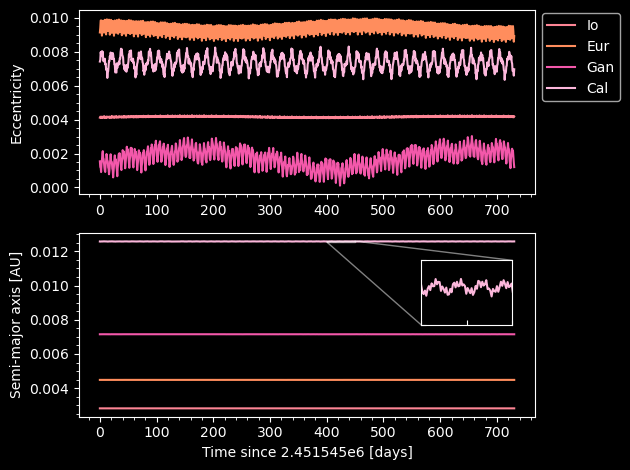

In [68]:
plt.style.use("dark_background")
fig,(ax,ax2)=subplots(2)
function plot_el(elem,ax)
ax.set_prop_cycle(co_cycle)
    for j=1:4
        ax.plot(times.-times[1],elem[j,:],label=obj_names[j])
    end

    return ax
end
plot_el(ecc,ax)
plot_el(smas,ax2)
# ax3=fig.add_axes([0.75,0.325,0.2,0.10])
# ax3.tick_params(labelbottom=true,labelleft=true,direction="in",which="both")

ax3 = ax2.inset_axes(    [0.75,0.50,0.2,0.35],
    xlim=(400, 450), ylim=(0.01255,0.0126), xticklabels=[], yticklabels=[])
# ax3.plot(times.-times[1],smas[5,:])
plot_el(smas,ax3)
ax2.indicate_inset_zoom(ax3, edgecolor="white")
# ax3.set_ylim(0.01256,0.0126)
# ax3.set_xlim(420,450)
ax.minorticks_on()
ax2.minorticks_on()
# fig.add_subplot(bbox_to_anchor=(0.5,0.5,0.5,0.5))
ax3.tick_params(direction="in",which="both",labelright=true)
ax.set_ylabel("Eccentricity");
ax2.set_ylabel("Semi-major axis [AU]");
ax2.set_xlabel("Time since $jd_start [days]");
ax.legend(bbox_to_anchor=(1,1.02))
fig.tight_layout()
savefig("galileo_converted_elems_J2000.pdf",dpi=150)

In [92]:
# include("../analytic_ttvs/ttv_ss/src/CGS.jl")
varpi[:,1]

4-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0

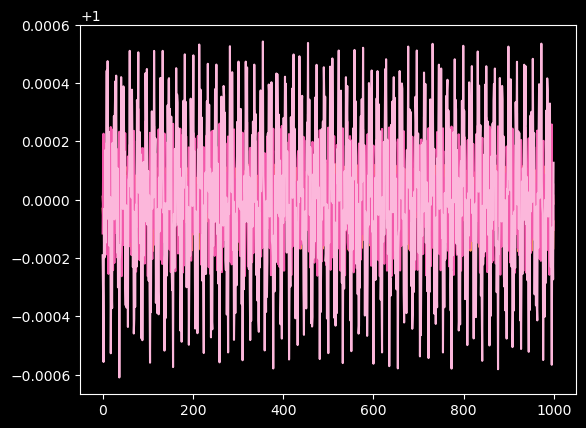

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff44cadd730>

In [71]:
fig,(ax2)=subplots(1)
ax2.set_prop_cycle(co_cycle)
ax2.plot((smas[1,:]./mean(smas[1,:])))#./CGS.RJUPITER )
ax2.plot((smas[2,:]./mean(smas[2,:])))#./CGS.RJUPITER)
ax2.plot((smas[3,:]./mean(smas[3,:])))#./CGS.RJUPITER)
ax2.plot((smas[4,:]./mean(smas[4,:])))#./CGS.RJUPITER)

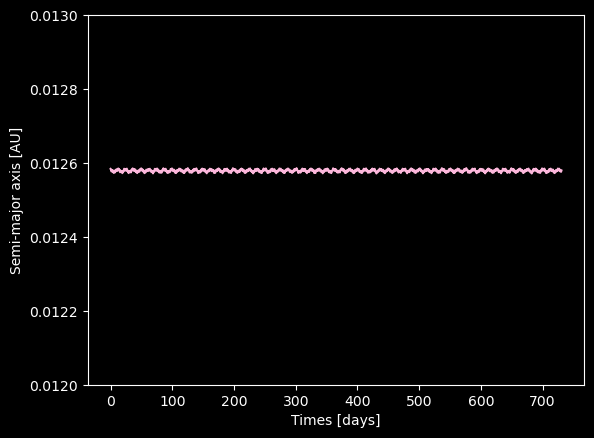

(0.012, 0.013)

In [57]:
fig,(ax2)=subplots(1)
plot_el(smas,ax2)
ax2.set_ylabel("Semi-major axis [AU]");
# ax2.set_xlim(0,100)
ax2.set_ylim(0.012,0.013)

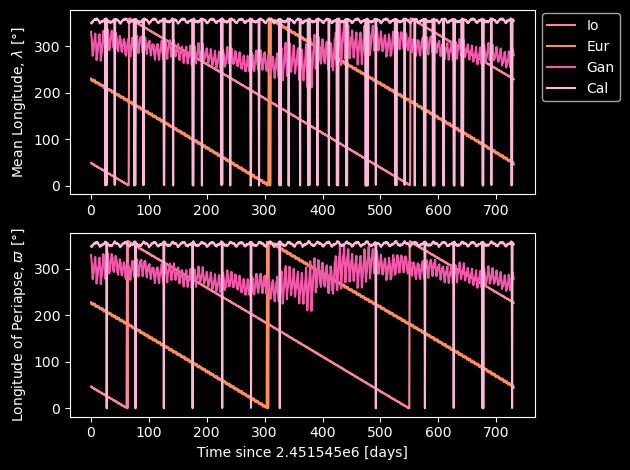

In [73]:
fig,(ax,ax2)=subplots(2)
plot_el(zeroTo360.(lon),ax)
ax.set_ylabel(L"Mean Longitude, $\lambda$ [$\degree$]");
plot_el(zeroTo360.(varpi),ax2)
ax2.set_ylabel(L"Longitude of Periapse, $\varpi$ [$\degree$]");
ax2.set_xlabel("Time since $jd_start [days]");
ax.legend(bbox_to_anchor=(1,1.02))
fig.tight_layout()
savefig("galileo_converted_angles_J2000.pdf",dpi=150)

calculate $\lambda$ from TTVs

In [74]:
calc_L(t,t0,P,esinw)=((360/P) .*(t.-t0)) .+2*esinw #mean longitude

calc_L (generic function with 1 method)

In [75]:
# nt1,nt2,nt3,nt4
io_range = 1:nt1
eur_range = nt1+1:nt1+nt2
gan_range = nt1+nt2+1:nt1+nt2+nt3
cal_range = nt1+nt2+nt3+1:nt1+nt2+nt3+nt4
ranges=[io_range,eur_range,gan_range,cal_range]

4-element Vector{UnitRange{Int64}}:
 1:412
 413:618
 619:720
 721:764

In [120]:
fitted_param_mmr

15-element Vector{Float64}:
  0.0001108775671394915
  1.7691379356157302
  1.376130395143807
 -0.0002865725290744652
  0.0014423060768409292
  2.7629828778110253e-5
  3.551181084221937
  1.5715070668796605
  0.0009624736103162797
  0.003847440996759272
  8.389588464529516e-5
  7.154553773776345
  3.7544946326807196
  0.003912768955026708
  0.010762544448977692

In [76]:
nts = [nt1,nt2,nt3,nt4]

4-element Vector{Int64}:
 412
 206
 102
  44

In [79]:
Pers_io = diff(tt[io_range]);
lambdas = zeros(3,length(times))
for i in 1:3
#     for j 
    lambdas[i,:] .= calc_L.(times,fitted_param_mmr_J2000[(i-1)*5 + 3],fitted_param_mmr_J2000[(i-1)*5 + 2],fitted_param_mmr_J2000[(i-1)*5 + 5])
end

In [217]:
# plot(times,zeroTo360.(lambdas[1,:]))

calculate the resonant arguments of the 2:1 Eur-Io resonance about 0
- similarly, Eur and Gan librade about 0
$\lambda_I$

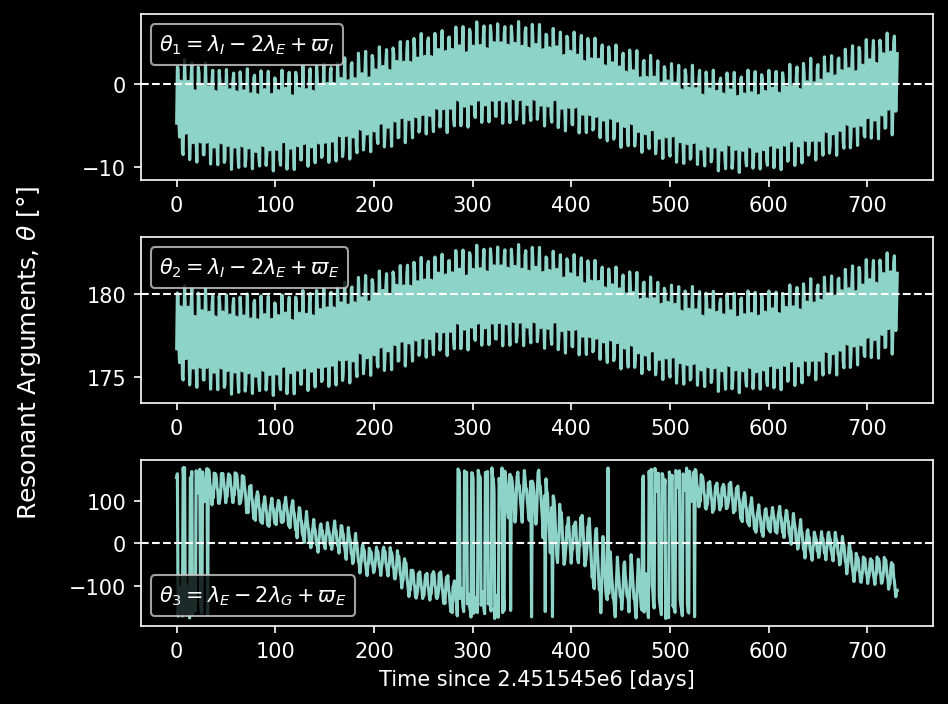

In [81]:
θ_io_eur = min180To180.(- 2 .* lon[2,:]  + lon[1,:] + varpi[1,:])
θ_eur_gan = min180To180.(- 2 .* lon[3,:]  + lon[2,:] + varpi[2,:])
θ_io_eur2 =zeroTo360.(- 2 * lon[2,:]  + lon[1,:] + varpi[2,:])
fig,(ax,ax3,ax2) = subplots(3,dpi=150)
# ax.set_prop_cycle(co_cycle)
ax.plot(times.-times[1],θ_io_eur,label=L"$\theta_1 = \lambda_I - 2 \lambda_E + \varpi_I$")
ax2.plot(times.-times[1],θ_eur_gan,label=L"$\theta_3 = \lambda_E - 2 \lambda_G + \varpi_E$")
ax.legend(handletextpad=0,handlelength=0,fancybox=true)
ax3.plot(times.-times[1],θ_io_eur2,label=L"$\theta_2 = \lambda_I - 2 \lambda_E + \varpi_E$")
ax3.legend(handletextpad=0,handlelength=0,fancybox=true)
ax2.legend(handletextpad=0,handlelength=0,fancybox=true)
ax.axhline(0.0,ls="--",lw=1);ax2.axhline(0.0,ls="--",lw=1)
fig.supylabel(L"Resonant Arguments, $\theta$ [$\degree$]")
ax2.set_xlabel("Time since $jd_start [days]")
ax3.axhline(180,ls="--",lw=1)
fig.tight_layout()

savefig("Resonant_args_actual_J2000.pdf")
# fig.legend()

Now look at the 3-body Laplace resonance angle, should be about $\pi$

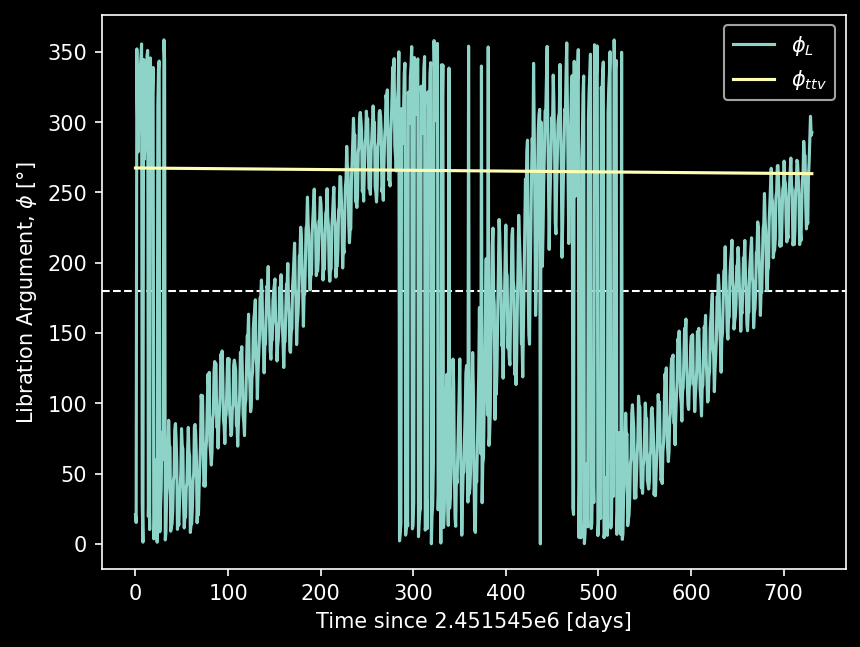

In [82]:
θ_laplace = zeroTo360.(- 3 .* lon[2,:]  + lon[1,:] + 2*lon[3,:])
θ_ttv = zeroTo360.(lambdas[1,:] .- (3 .* lambdas[2,:]) .+( 2 .* lambdas[3,:]))

fig,ax = subplots(1,dpi=150)
ax.axhline(180,ls="--",lw=1.0)
ax.plot(times.-times[1],θ_laplace,label=L"$\phi_L$")
ax.plot(times.-times[1],θ_ttv,label=L"$\phi_{ttv}$")
ax.set_ylabel(L"Libration Argument, $\phi$ [$\degree$]")
ax.set_xlabel("Time since $jd_start [days]")
ax.legend()
# ax.legend(title=L"$\theta = \lambda_I - 2 \lambda_E + \varpi_I$")
savefig("TTV_libration_J2000.pdf")

Now compute lambdas from the best_fit params, and find the ttv resonance angle per Siegel & Fabrycky 2021

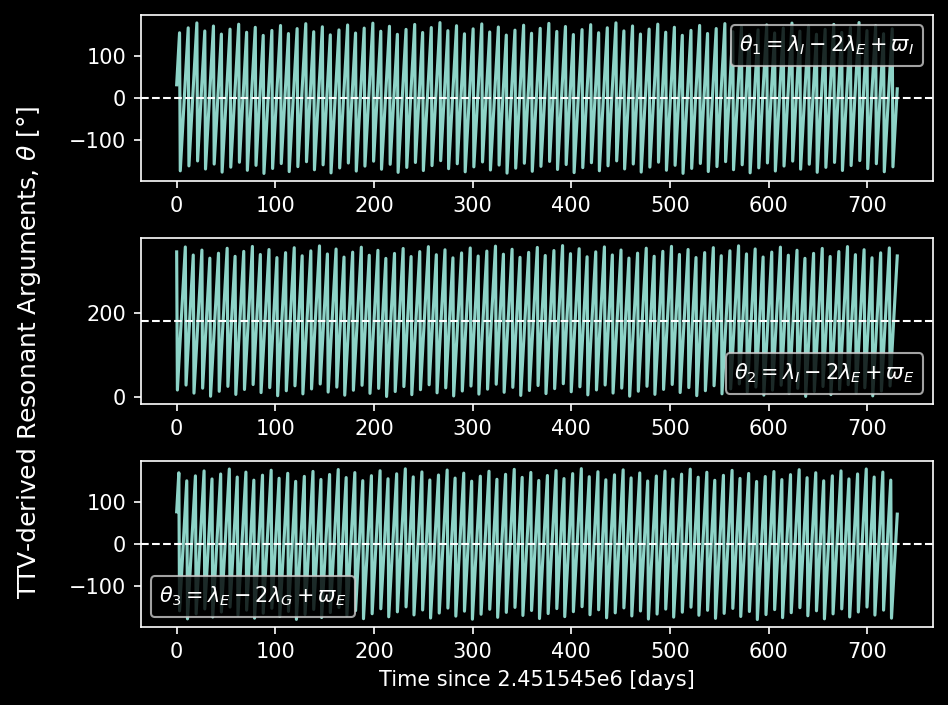

In [84]:
# θ_ttv = zeroTo360.(lambdas[1,:] .- (3 .* lambdas[2,:]) .+( 2 .* lambdas[3,:]))
ϖ = [atan.(fitted_param_mmr_J2000[(i-1)*5 + 4],fitted_param_mmr_J2000[(i-1)*5 + 5]) for i=1:3]
θ_io_eur = min180To180.(- 2 .* lambdas[2,:]  + lambdas[1,:] .+ ϖ[1])
θ_eur_gan = min180To180.(- 2 .* lambdas[3,:]  + lambdas[2,:] .+ ϖ[2])
θ_io_eur2 =zeroTo360.(- 2 * lambdas[2,:]  + lambdas[1,:] .+ ϖ[2])

fig,(ax,ax3,ax2) = subplots(3,dpi=150)
ax.plot(times.-times[1],θ_io_eur,label=L"$\theta_1 = \lambda_I - 2 \lambda_E + \varpi_I$")
ax2.plot(times.-times[1],θ_eur_gan,label=L"$\theta_3 = \lambda_E - 2 \lambda_G + \varpi_E$")
ax.legend(handletextpad=0,handlelength=0,fancybox=true)
ax3.plot(times.-times[1],θ_io_eur2,label=L"$\theta_2 = \lambda_I - 2 \lambda_E + \varpi_E$")
ax3.legend(handletextpad=0,handlelength=0,fancybox=true)
ax2.legend(handletextpad=0,handlelength=0,fancybox=true)
ax.axhline(0.0,ls="--",lw=1);ax2.axhline(0.0,ls="--",lw=1);ax3.axhline(180,ls="--",lw=1)
fig.supylabel(L"TTV-derived Resonant Arguments, $\theta$ [$\degree$]")
ax2.set_xlabel("Time since $jd_start [days]")
fig.tight_layout()
savefig("Resonant_args_derived_J2000.pdf")

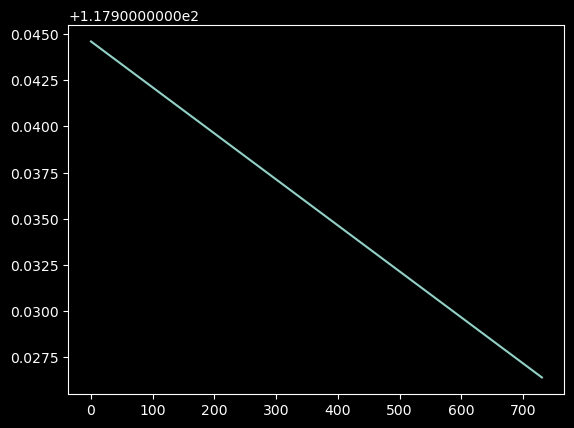

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff46fec7310>

In [227]:
calc_lambda(t,t0,P,esinw,ecosw) = π/2 + (2 * pi * (t-t0) / P ) - (2* ecosw) + (3*ecosw*esinw/2)
lambda_t = zeros(3,length(times))
for i in 1:3
    lambda_t[i,:] .= calc_lambda.(times,fitted_param_mmr[(i-1)*5 + 3],fitted_param_mmr[(i-1)*5 + 2],fitted_param_mmr[(i-1)*5 + 4],fitted_param_mmr[(i-1)*5 + 5])
end
θ_ttv_siegel = zeroTo360.(lambda_t[1,:] .- (3 .* lambda_t[2,:]) .+( 2 .* lambda_t[3,:]))
plot(times.-times[1],θ_ttv_siegel)

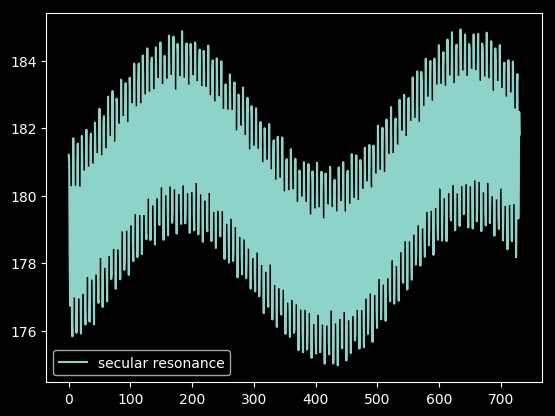

PyObject <matplotlib.legend.Legend object at 0x7fbbfa7687b8>

In [162]:
# theta = min180To180.(2 .* lon[2,:] .- lon[1,:] .- varpi[1,:])
# plot(collect(times).-times[1],theta)
theta_sec = zeroTo360.(-varpi[2,:] .+ varpi[1,:])
plot(collect(times).-times[1],theta_sec,label="secular resonance")
# ylim(-180,360)
legend()

In [149]:
mmr_angle(p,q,λ_out,λ_in,ω_out_in)= (p+q)*λ_out - p * λ_in - q * ω_out_in
function mmr_angle(x,angles)
    n=size(angles,2)
    y=zeros(n)
    for i in 1:n
        λ2,λ1,ω12=angles[1,i],angles[2,i],angles[3,i]
        y[i]=(x[1].+x[2]).* λ2 .- (x[1] .* λ1 ).- x[2] .* ω12
    end
    return y
end

mmr_angle (generic function with 2 methods)

In [326]:
fitted_param_mmr[414+206:end]

Float64[]

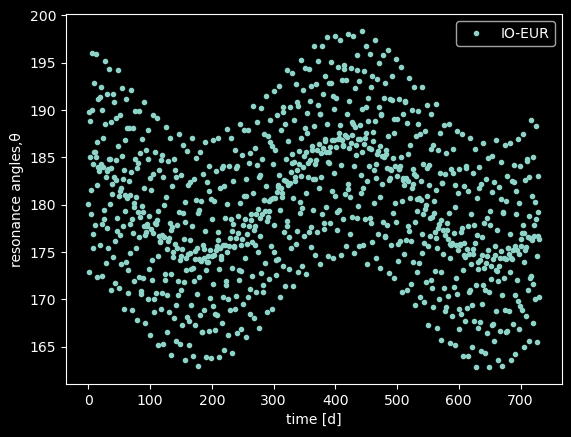

PyObject <matplotlib.legend.Legend object at 0x7ff4d446abb0>

In [177]:
# fig,(ax,ax2) = subplots(2,dpi=150)
plot(times.-times[1],zeroTo360.(mmr_angle.(1.0,2.0,lon[2,:],lon[1,:],varpi[1,:])),
    ".",label="IO-EUR")
# plot(times.-times[1],zeroTo360.(mmr_angle.(1.0,2.0,lon[3,:],lon[2,:],varpi[2,:])),
#     ".",label="EUR-GAN")

xlabel("time [d]")
ylabel("resonance angles,θ")
legend()

In [370]:
using NbodyGradient

┌ Info: Precompiling NbodyGradient [69f646f0-5709-4f35-9e52-1656edff0883]
└ @ Base loading.jl:1342


In [61]:
function compute_λ!(jmax::Integer,p1::TTVFaster.Planet_plane_hk{T},p2::TTVFaster.Planet_plane_hk{T},time1::Vector{T},time2::Vector{T},
            ttv1::Vector{T},ttv2::Vector{T},
            lam1::Vector{T},lam2::Vector{T}) where T<:Real
  # Compute the semi-major axis ratio of the planets:
  # println(p1.period,p2.period)
  alpha = (p1.period/p2.period)^(2//3)  
  #println(alpha, p1.period, p2.period)
  @assert(alpha < 1)
  @assert(alpha > 0)
  # Number of times:
   ntime1 = length(time1)
   ntime2 = length(time2)
  f1=zeros(T,jmax+2,5)  
  f2=zeros(T,jmax+2,5)  
  # Compute the coefficients:
  TTVFaster.ttv_succinct!(jmax+1,alpha,f1,f2)  # I need to compute coefficients one higher than jmax
  # Compute TTVs for inner planet (equation 33):
  # Compute since of \pomegas:
  e1 = sqrt(p1.esinw*p1.esinw + p1.ecosw*p1.ecosw)
  e2 = sqrt(p2.esinw*p2.esinw + p2.ecosw*p2.ecosw)
  sin1om=p1.esinw/e1
  sin2om=p2.esinw/e2
  cos1om=p1.ecosw/e1
  cos2om=p2.ecosw/e2
  # Compute mean motions:
  n1=2pi/p1.period
  n2=2pi/p2.period
  # Compute initial longitudes:
  lam10=-n1*p1.trans0 + 2*p1.esinw # 2*p1.eccen*sin1om
  lam20=-n2*p2.trans0 + 2*p2.esinw # 2*p2.eccen*sin2om
  @inbounds for i=1:ntime1
  # Compute the longitudes of the planets at times of transit of planet 1 (equation 49):
    lam11 = n1*time1[i]+lam10
    lam21 = n2*time1[i]+lam20
    psi1  = lam11-lam21 # Compute difference in longitudes at times of transit of planet 1
    sinpsi1=sin(psi1)
    cospsi1=cos(psi1)
    sinlam11 = sin(lam11)
    coslam11 = cos(lam11)
    sinlam1om1=sinlam11*cos1om - coslam11*sin1om
    coslam1om1=coslam11*cos1om + sinlam11*sin1om
    sinlam1om2=sinlam11*cos2om - coslam11*sin2om
    coslam1om2=coslam11*cos2om + sinlam11*sin2om
    ttv1[i]=zero(T) #0.0
    sinjm1psi1=zero(T) #0.0
    cosjm1psi1=one(T) #1.0
  # Sum over j:
    for j=1:jmax
      sinjpsi1=sinjm1psi1*cospsi1 + cosjm1psi1*sinpsi1
      cosjpsi1=cosjm1psi1*cospsi1 - sinjm1psi1*sinpsi1
      ttv1[i] += f1[j+1,1]*sinjpsi1
      ttv1[i] += f1[j+1,2]*e1*(sinjpsi1*coslam1om1 - cosjpsi1*sinlam1om1)
      ttv1[i] += f1[j+1,3]*e1*(sinjpsi1*coslam1om1 + cosjpsi1*sinlam1om1)
      ttv1[i] += f1[j  ,4]*e2*(sinjpsi1*coslam1om2 - cosjpsi1*sinlam1om2)
      ttv1[i] += f1[j+2,5]*e2*(sinjpsi1*coslam1om2 + cosjpsi1*sinlam1om2)
      sinjm1psi1=sinjpsi1
      cosjm1psi1=cosjpsi1
    end
  # Multiply by period and mass ratio, and divide by 2*Pi:
    ttv1[i] = ttv1[i]*p1.period*p2.mass_ratio/(2pi)
    lam1[i] =  atan(sinlam11, coslam11)
  end
  # Compute TTVs for outer planet (equation 33):
  @inbounds for i=1:ntime2
  # Compute the longitudes of the planets at times of transit of planet 2:
    lam12 = n1*time2[i]+lam10
    lam22 = n2*time2[i]+lam20
    sinlam22 = sin(lam22)
    coslam22 = cos(lam22)
    psi2  = lam12-lam22 # Compute difference in longitudes at times of transit of planet 2
    sinpsi2=sin(psi2)
    cospsi2=cos(psi2)
    sinlam2om1=sinlam22*cos1om - coslam22*sin1om
    coslam2om1=coslam22*cos1om + sinlam22*sin1om
    sinlam2om2=sinlam22*cos2om - coslam22*sin2om
    coslam2om2=coslam22*cos2om + sinlam22*sin2om
    ttv2[i]=zero(p2.period) #0.0
    sinjm1psi2=zero(p2.period) #0.0
    cosjm1psi2=one(p2.period) #1.0
  # Sum over j:
    for j=1:jmax
      sinjpsi2=sinjm1psi2*cospsi2 + cosjm1psi2*sinpsi2
      cosjpsi2=cosjm1psi2*cospsi2 - sinjm1psi2*sinpsi2
      ttv2[i] += f2[j+1,1]*sinjpsi2
      ttv2[i] += f2[j+1,2]*e2*(sinjpsi2*coslam2om2 - cosjpsi2*sinlam2om2)
      ttv2[i] += f2[j+1,3]*e2*(sinjpsi2*coslam2om2 + cosjpsi2*sinlam2om2)
      ttv2[i] += f2[j+2,4]*e1*(sinjpsi2*coslam2om1 - cosjpsi2*sinlam2om1)
      ttv2[i] += f2[j  ,5]*e1*(sinjpsi2*coslam2om1 + cosjpsi2*sinlam2om1)
      sinjm1psi2=sinjpsi2
      cosjm1psi2=cosjpsi2
    end
  # Multiply by period and mass ratio, and divide by 2*Pi:
    ttv2[i] = ttv2[i]*p2.period*p1.mass_ratio/(2pi)
    lam2[i] =  atan(sinlam22, coslam22)
  end
return
end

compute_λ! (generic function with 1 method)

In [68]:

function λ_nplanet(nplanet::Int64,jmax::Int64,ntrans::Vector{Int64},
        params::Vector{T}) where T<:Real
      # The ntrans vectors should have length nplanet:
  @assert(length(ntrans)==nplanet)
    ntransmax = maximum(ntrans)
  λs = zeros(T,nplanet,ntransmax)
     @assert(length(params)==5*nplanet)
  @assert(jmax>=1)  
  for iplanet=1:nplanet
  # Each planet should have at least 2 transits:
    @assert(ntrans[iplanet]>=2)
  end
  for iplanet=1:nplanet-1
  # The periods of the planets should be ordered from least to greatest:
    if (params[(iplanet-1)*5+2] >= params[iplanet*5+2])
      return ttv
    end
  end
  for iplanet=1:nplanet-1
    # Create a Planet_plane_hk type for the inner planet:
    p1=Planet_plane_hk(params[(iplanet-1)*5+1],params[(iplanet-1)*5+2],params[(iplanet-1)*5+3],params[(iplanet-1)*5+4],params[(iplanet-1)*5+5])
    # Create an array of times for the inner planet:
    n1 = ntrans[iplanet]
    time1 = collect(p1.trans0 .+ range(0,stop=n1-1,length=n1) .* p1.period)
    # Loop over outer planets:
    for jplanet=iplanet+1:nplanet
        # Create a Planet_plane_hk type for the outer planet:
        p2=Planet_plane_hk(params[(jplanet-1)*5+1],params[(jplanet-1)*5+2],params[(jplanet-1)*5+3],params[(jplanet-1)*5+4],params[(jplanet-1)*5+5])
        # Create an array of times for the outer planet:
        n2 = ntrans[jplanet]
        time2 = collect(p2.trans0 .+ range(0,stop=n2-1,length=n2) .* p2.period)
        # Define arrays to hold the TTVs:
        ttv1=zeros(T,n1)
        ttv2=zeros(T,n2)
        lam1=zeros(T,n1)
        lam2=zeros(T,n2)
        # Call the compute_ttv code which implements equation (33) from Agol & Deck (2016):
        #    println("Calling compute_ttv")
        compute_λ!(jmax,p1,p2,time1,time2,ttv1,ttv2,lam1,lam2)
        #    println("Finished compute_ttv")
              for i=1:n1
                λs[iplanet,i] += lam1[i]
              end
              for i=1:n2
                λs[jplanet,i] += lam2[i]
              end
    end
end
    return λs
end

λ_nplanet (generic function with 1 method)

In [69]:
lam=λ_nplanet(4,5,[nt1,nt2,nt3,nt4],fitted_param)

4×413 Matrix{Float64}:
 0.110661  0.110661  0.110661  0.110661  …  0.110661  0.110661  0.110661
 0.201303  0.201303  0.201303  0.201303     0.0       0.0       0.0
 0.461305  0.461305  0.461305  0.461305     0.0       0.0       0.0
 0.228938  0.228938  0.228938  0.228938     0.0       0.0       0.0

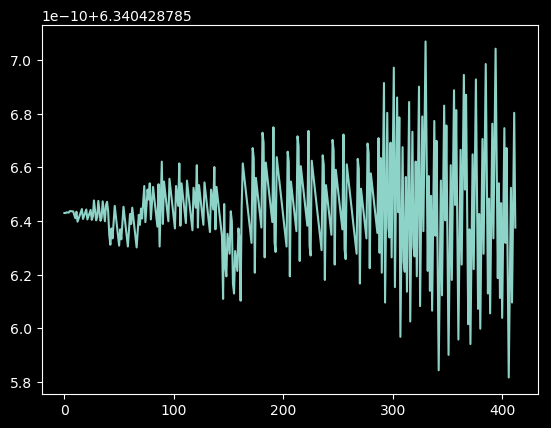

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fbbf9ebd5c0>

In [123]:
plot(min180To180.(lam[1,:]))

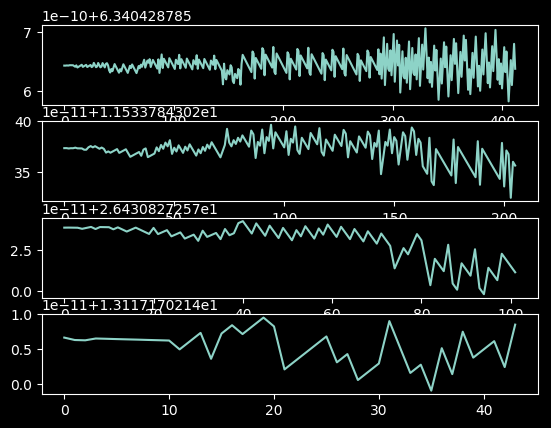

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fbbf64185c0>

In [80]:
fig,axs=subplots(4)
axs[1].plot(rad2deg.(lam[1,:]))
axs[2].plot(rad2deg.(lam[2,1:nt2]))
axs[3].plot(rad2deg.(lam[3,1:nt3]))
axs[4].plot(rad2deg.(lam[4,1:nt4]))

In [66]:
lam[2]

206-element Vector{Float64}:
 0.06710083709708625
 0.06710083709708646
 0.06710083709708443
 0.06710083709708595
 0.06710083709708571
 0.06710083709708903
 0.06710083709708524
 0.06710083709708499
 0.06710083709708474
 0.06710083709707738
 0.06710083709707713
 0.06710083709709111
 0.06710083709709797
 ⋮
 0.06710083709699653
 0.06710083709697498
 0.06710083709695341
 0.06710083709693186
 0.06710083709691028
 0.06710083709711612
 0.06710083709686718
 0.067100837097073
 0.06710083709705145
 0.06710083709680251
 0.06710083709700833
 0.06710083709698675

In [67]:
lam[3]

LoadError: BoundsError: attempt to access Tuple{Vector{Float64}, Vector{Float64}} at index [3]